## **1. Làm Sạch và Tiền Xử Lý Dữ Liệu (Data Cleaning & Preprocessing)**

#### **1.1 Nhập dữ liệu và cài đặt**

In [1]:
import pandas as pd
import numpy as np
import unicodedata
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from IPython.display import display

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


#### **1.2. Đọc Dữ Liệu và Khảo Sát Ban Đầu**

In [2]:
# Cell đọc dữ liệu raw
current_dir = Path(os.getcwd())
file_path = (current_dir / 'data' / 'raw' / 'fulldata_raw_4web.csv') if (current_dir / 'data' / 'raw' / 'fulldata_raw_4web.csv').exists() else (current_dir.parent.parent / 'data' / 'raw' / 'fulldata_raw_4web.csv')
df_raw = pd.read_csv(file_path, encoding='utf-8-sig')

print(f"Shape ban đầu: {df_raw.shape}")
print("\nPHÂN BỐ DỮ LIỆU BAN ĐẦU:")
print("\nTheo Nguồn:")
print(df_raw['Nguồn'].value_counts())

print(f"\nSố dòng: {len(df_raw):,} | Số cột: {len(df_raw.columns)}")
display(df_raw.head(3))


Shape ban đầu: (163538, 16)

PHÂN BỐ DỮ LIỆU BAN ĐẦU:

Theo Nguồn:
Nguồn
batdongsan    76748
nhadat24h     59913
alonhadat     17537
meeyland       9340
Name: count, dtype: int64

Số dòng: 163,538 | Số cột: 16


,Tiêu đề,Giá,Diện tích,Giá/m2,Địa chỉ,Ngày đăng,Số phòng ngủ,Số phòng vệ sinh,Số phòng tắm,Số tầng,Chỗ để xe,Kích thước,Mặt tiền,Đường vào,Loại BĐS,Nguồn
0,🍀🍀🍀Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang ch...,630 triệu,120 m²,NaN,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",08/10/2025,3.0,NaN,NaN,1.0,Có,6x19m,NaN,8m,NaN,alonhadat
1,Kẹt tiền nên chú Hai cần bán gấp 2 căn nhà đan...,650 triệu,120 m²,NaN,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",08/10/2025,3.0,NaN,NaN,2.0,Không,6x20m,NaN,8m,NaN,alonhadat
2,"Lô Đất Mặt Tiền Đường 12m Khu View Sông 6x20,5...","5,85 tỷ",123 m²,NaN,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh",08/10/2025,NaN,NaN,NaN,NaN,Không,6x23m,NaN,10m,NaN,alonhadat


#### **1.3. Kiểm tra kiểu dữ liệu**

In [3]:
print(f"Kiểu dữ liệu ban đầu:\n")
print(df_raw.dtypes)

Kiểu dữ liệu ban đầu:

Tiêu đề              object
Giá                  object
Diện tích            object
Giá/m2               object
Địa chỉ              object
Ngày đăng            object
Số phòng ngủ        float64
Số phòng vệ sinh    float64
Số phòng tắm        float64
Số tầng              object
Chỗ để xe            object
Kích thước           object
Mặt tiền             object
Đường vào            object
Loại BĐS             object
Nguồn                object
dtype: object


* **Nhận xét:**
    * Các cột đã đúng định dạng số: `Số phòng ngủ`, `Số phòng vệ sinh`, `Số phòng tắm`.
    * Các cột quan trọng bị sai định dạng (object): `Giá`, `Diện tích`, `Giá/m2`, `Số tầng`, `Mặt tiền`, `Đường vào`.
    * Các cột cần xử lý đặc biệt:
        * `Ngày đăng`: Cần chuyển sang `datetime`.
        * `Kích thước`: Cần tách thành `Chiều rộng`, `Chiều dài`.
        * `Địa chỉ`: Cần tách thành `Quận`.
        * `Loại BĐS`: Cần chuẩn hóa và suy luận từ cột `Tiêu đề` 
* **Nguyên nhân:** Dữ liệu thô chứa ký tự chữ, đơn vị ("triệu", "tỷ", "m²", "m"), hoặc giá trị text ("Thỏa thuận").
* **Bước tiếp theo:** Tiền xử lý để làm sạch và chuyển đổi các cột này về đúng định dạng.

#### **1.4. Kiểm tra và xử lý dữ liệu trùng lặp**

In [4]:
# Kiểm tra dữ liệu xem có tồn tại dòng dữ liệu nào bị trùng lặp hay không 
sum(df_raw.duplicated())

0

* Nhận xét: Không có dòng nào bị trùng lặp hoàn toàn

#### **1.5. Phân Tích Giá Trị Thiếu (Missing Values)**

##### **1.5.1. Tỷ lệ thiếu tổng thể**

In [5]:
# Tỉ lệ giá trị bị thiếu ở mỗi cột

missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
missing_pct = missing_pct.sort_values(ascending=False)

print("TỶ LỆ THIẾU THEO CỘT (%):")
display(missing_pct.to_frame(name="Missing_%"))

TỶ LỆ THIẾU THEO CỘT (%):


,Missing_%
Số phòng tắm,96.88
Kích thước,90.46
Mặt tiền,76.59
Số tầng,75.46
Loại BĐS,75.14
Đường vào,64.51
Chỗ để xe,52.64
Giá/m2,51.23
Số phòng vệ sinh,48.48
Số phòng ngủ,44.78


* Dữ liệu tốt, không thiếu: Tiêu đề, Giá, Diện tích, Địa chỉ, Ngày đăng, Nguồn
* Dữ liệu thiếu nghiêm trọng (Lý do cào nhiều trang web, một số trang không có dữ liệu của trang web khác nên dẫn tới dữ liệu một số cột bị thiếu nặng nề)
    * Số phòng tắm: 96,8%
    * Kích thước: 90,4%
    * Mặc tiền: 76,5%
    * Số tầng: 75,4%
    * Loại BĐS: 75,1%
    * Đương vào: 64.5%
* Dữ liệu cân nhắc:
    * Chỗ để xe:: 52,6%
    * Số phòng vệ sinh: 48.4%
    * Số phòng ngủ: 44.7%
* Giá/m2: tái tại được vì: Giá / Diện tích = Giá/m2 (Giá và Diện tích gần như là đầy đủ, không bị thiếu dữ liệu)

##### **1.5.2. Tỷ lệ thiếu theo từng nguồn**

In [6]:
def show_missing_by_source(df, src):
    sub = df[df['Nguồn'] == src].copy()

    if len(sub) == 0:
        print(f"Không có dữ liệu cho nguồn: {src}")
        return

    missing_src_stats = pd.DataFrame({
        'Missing': sub.isna().sum(),
        'Percent_%': (sub.isna().sum() / len(sub) * 100).round(2)
    }).sort_values('Percent_%', ascending=False)

    print(f"\nTHỐNG KÊ GIÁ TRỊ THIẾU - {src.upper()} ({len(sub):,} dòng)\n")
    display(missing_src_stats[missing_src_stats['Missing'] > 0])
# batdongsan
show_missing_by_source(df_raw, 'batdongsan')



THỐNG KÊ GIÁ TRỊ THIẾU - BATDONGSAN (76,748 dòng)



,Missing,Percent_%
Số phòng tắm,76748,100.00
Số tầng,76748,100.00
Chỗ để xe,76748,100.00
Kích thước,76748,100.00
Mặt tiền,76748,100.00
Đường vào,76748,100.00
Loại BĐS,76748,100.00
Số phòng vệ sinh,29009,37.80
Số phòng ngủ,26509,34.54
Giá/m2,6039,7.87


* Nhận xét trang Batdongsan: Thiếu hoàn toàn Số phòng tắm, Số tầng, Chỗ đề xe, Kích thước, Mặt tiền, Đường vào, Loại BĐS

In [7]:
# alonhadat
show_missing_by_source(df_raw, 'alonhadat')


THỐNG KÊ GIÁ TRỊ THIẾU - ALONHADAT (17,537 dòng)



,Missing,Percent_%
Giá/m2,17537,100.00
Số phòng vệ sinh,17537,100.00
Số phòng tắm,17537,100.00
Mặt tiền,17537,100.00
Loại BĐS,17537,100.00
Kích thước,1939,11.06
Số tầng,1772,10.10
Số phòng ngủ,1466,8.36
Đường vào,60,0.34


* Alonhadat: Thiếu hoàn toàn Giá/m2, Số phòng vệ sinh, Số phòng tắm, Mặt tiền, Loại BĐS




In [8]:
# meeyland
show_missing_by_source(df_raw, 'meeyland')


THỐNG KÊ GIÁ TRỊ THIẾU - MEEYLAND (9,340 dòng)



,Missing,Percent_%
Số phòng vệ sinh,9340,100.00
Số tầng,9340,100.00
Chỗ để xe,9340,100.00
Kích thước,9340,100.00
Mặt tiền,9340,100.00
Đường vào,9340,100.00
Loại BĐS,9340,100.00
Số phòng tắm,4241,45.41
Số phòng ngủ,3629,38.85
Giá/m2,290,3.10



* Meeyland: Thiếu hoàn toàn Số phòng tắm, Số tầng, Chỗ đề xe, Kích thước, Mặt tiền, Đường vào, Loại BĐS





In [9]:
# nhadat24h
show_missing_by_source(df_raw, 'nhadat24h')


THỐNG KÊ GIÁ TRỊ THIẾU - NHADAT24H (59,913 dòng)



,Missing,Percent_%
Giá/m2,59913,100.00
Số phòng tắm,59913,100.00
Kích thước,59913,100.00
Số phòng ngủ,41625,69.48
Số tầng,35552,59.34
Số phòng vệ sinh,23391,39.04
Mặt tiền,21636,36.11
Đường vào,19355,32.31
Loại BĐS,19251,32.13



* Nhadat24h: Có dữ liệu đầy đủ nhất, chỉ thiếu Giá/m2 và Số phòng tắm và Kích thước



## **2. Xây Dựng Các Hàm Tiền Xử Lý**

*Các hàm tiện ích này được xây dựng để chuyển đổi dữ liệu thô về đúng kiểu dữ liệu và thống nhất định dạng trước khi phân tích.*

#### **2.1. Chuẩn hóa giá, diện tích, kích thước, số đo**

Chuyển các giá trị dạng text (ví dụ: `"5,8 tỷ"`, `"120 m²"`, `"6x19m"`, `"8m"`) về dạng số để tính toán.

**Giải thích:**
- `parse_number`: chuẩn hóa chuỗi số, xử lý cả định dạng VN/US với dấu `.` và `,`.
- `clean_gia`: quy đổi giá về VND (`tỷ`, `triệu`, `nghìn/k`); các trường hợp như `"thỏa thuận"`, `"liên hệ"` được gán `None`.
- `clean_dien_tich`: lấy giá trị diện tích/số đo từ chuỗi; hỗ trợ đổi `ha` sang `m²`.
- `tach_kich_thuoc`: tách chuỗi dạng `R x D` (ví dụ: `"6x19m"`) thành `ChieuRong_tach` và `ChieuDai_tach`.
- `Mặt tiền` và `Đường vào` được chuẩn hóa bằng `clean_dien_tich` để thống nhất kiểu dữ liệu.
- Kết quả được minh họa bằng bảng demo, bảng preview dữ liệu thật, và bảng `summary` (NonNull/Missing/Missing_%).

In [10]:
# 2.1A - Hàm chuẩn hóa số, giá, diện tích, kích thước + helper format hiển thị

import re
import unicodedata
import pandas as pd
import numpy as np

NUM_PATTERN = re.compile(r"\d[\d\.,]*")

def normalize_text_vn(text):
    if text is None:
        return ""
    s = str(text).strip().lower()
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")
    return s

def parse_number(token, decimal_hint=False):
    """
    Parse chuỗi số có thể chứa dấu . và ,
    Ví dụ:
    - 1.234,56 -> 1234.56
    - 1,234.56 -> 1234.56
    - 1.200.000 -> 1200000
    - 1,5 -> 1.5
    - 11,787 (nếu decimal_hint=True) -> 11.787
    """
    if token is None:
        return None

    s = re.sub(r"[^\d\.,]", "", str(token).strip())
    if not s:
        return None

    if "." in s and "," in s:
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            s = s.replace(",", "")
    elif "," in s:
        if s.count(",") == 1:
            left, right = s.split(",")
            s = left + "." + right if (decimal_hint or len(right) != 3) else left + right
        else:
            s = s.replace(",", "")
    elif "." in s:
        if s.count(".") == 1:
            left, right = s.split(".")
            s = left + "." + right if (decimal_hint or len(right) != 3) else left + right
        else:
            s = s.replace(".", "")

    try:
        return float(s)
    except ValueError:
        return None

def clean_gia(x):
    """Chuẩn hóa giá về VND (float)."""
    if pd.isna(x):
        return None

    raw = str(x).strip()
    norm = normalize_text_vn(raw)

    if any(k in norm for k in ["thoa thuan", "thuong luong", "lien he"]):
        return None

    # Bắt trường hợp kiểu: "3 tỷ 386 triệu"
    combo = re.search(r"(\d[\d\.,]*)\s*ty\s*(\d[\d\.,]*)\s*(tr|trieu)", norm)
    if combo:
        ty = parse_number(combo.group(1), decimal_hint=True)
        trieu = parse_number(combo.group(2), decimal_hint=True)
        if ty is not None and trieu is not None:
            return ty * 1_000_000_000 + trieu * 1_000_000

    m = NUM_PATTERN.search(raw)
    if not m:
        return None

    is_ty = "ty" in norm
    is_trieu = "trieu" in norm or re.search(r"\btr\b", norm)

    # Với giá theo tỷ/triệu, dấu "," hoặc "." thường là phần thập phân
    num = parse_number(m.group(0), decimal_hint=is_ty or is_trieu)
    if num is None:
        return None

    if is_ty:
        return num * 1_000_000_000
    if is_trieu:
        return num * 1_000_000

    # bắt cả "700k", "700 k", "700nghin", "700 ngan"
    if re.search(r"(\d)\s*k\b", norm) or re.search(r"\bk\b", norm) or "nghin" in norm or "ngan" in norm:
        return num * 1_000

    # không có đơn vị -> chỉ giữ nếu đủ lớn để coi là VND
    return num if num >= 1_000_000 else None

def clean_dien_tich(x):
    """Chuẩn hóa diện tích/số đo về float; hỗ trợ ha -> m2."""
    if pd.isna(x):
        return None

    raw = str(x).strip()
    norm = normalize_text_vn(raw)

    m = NUM_PATTERN.search(raw)
    if not m:
        return None

    val = parse_number(m.group(0))
    if val is None:
        return None

    if "ha" in norm:
        return val * 10_000
    return val

def tach_kich_thuoc(x):
    """Tách kích thước dạng RxD -> (rộng, dài)."""
    if pd.isna(x):
        return (None, None)

    m = re.search(r"([\d][\d\.,]*)\s*[xX×*]\s*([\d][\d\.,]*)", str(x))
    if not m:
        return (None, None)

    rong = parse_number(m.group(1))
    dai = parse_number(m.group(2))

    if rong is None or dai is None or rong <= 0 or dai <= 0:
        return (None, None)
    return (rong, dai)

# helper format có dấu phân cách hàng nghìn
fmt0 = lambda v: f"{v:,.0f}" if pd.notna(v) else ""
fmt1 = lambda v: f"{v:,.1f}" if pd.notna(v) else ""
fmt2 = lambda v: f"{v:,.2f}" if pd.notna(v) else ""


In [11]:
# 2.1B - Demo test case (minh họa rõ hàm chạy ra gì)

demo = pd.DataFrame({
    "num_raw": ["1.234,56", "1,234.56", "1.200.000", "1,200,000", "1,5", "1.5", None],
    "gia_raw": ["5,8 tỷ", "950 tr", "1.200.000.000", "4500000000", "700k", "Thỏa thuận", "liên hệ"],
    "dt_raw": ["120 m²", "1.250 m2", "4,5m", "0.8 ha", "35", None, "N/A"],
    "kt_raw": ["6x19m", "4.5 x 20", "5,2×18,6", "ngang 4 dài 12", None, "7*15", "10 X 30"]
})

demo["num_parsed"] = demo["num_raw"].apply(parse_number)
demo["gia_vnd"] = demo["gia_raw"].apply(clean_gia)
demo["gia_ty"] = demo["gia_vnd"] / 1e9
demo["dien_tich_clean"] = demo["dt_raw"].apply(clean_dien_tich)
demo[["chieu_rong", "chieu_dai"]] = demo["kt_raw"].apply(lambda v: pd.Series(tach_kich_thuoc(v)))

display(
    demo.style.format({
        "num_parsed": fmt2,
        "gia_vnd": fmt0,
        "gia_ty": fmt2,
        "dien_tich_clean": fmt1,
        "chieu_rong": fmt1,
        "chieu_dai": fmt1
    })
)


,num_raw,gia_raw,dt_raw,kt_raw,num_parsed,gia_vnd,gia_ty,dien_tich_clean,chieu_rong,chieu_dai
0,"1.234,56","5,8 tỷ",120 m²,6x19m,"1,234.56","5,800,000,000",5.80,120.0,6.0,19.0
1,"1,234.56",950 tr,1.250 m2,4.5 x 20,"1,234.56","950,000,000",0.95,"1,250.0",4.5,20.0
2,1.200.000,1.200.000.000,"4,5m","5,2×18,6","1,200,000.00","1,200,000,000",1.20,4.5,5.2,18.6
3,"1,200,000",4500000000,0.8 ha,ngang 4 dài 12,"1,200,000.00","4,500,000,000",4.50,"8,000.0",,
4,"1,5",700k,35,None,1.50,"700,000",0.00,35.0,,
5,1.5,Thỏa thuận,None,7*15,1.50,,,,7.0,15.0
6,None,liên hệ,N/A,10 X 30,,,,,10.0,30.0


In [12]:
# 2.1C - Minh họa trên 10 dòng dữ liệu thật + summary thiếu dữ liệu

preview = df_raw[["Giá", "Diện tích", "Kích thước", "Mặt tiền", "Đường vào"]].head(10).copy()

preview["Gia_clean_vnd"] = preview["Giá"].apply(clean_gia)
preview["DienTich_clean"] = preview["Diện tích"].apply(clean_dien_tich)
preview[["ChieuRong_tach", "ChieuDai_tach"]] = preview["Kích thước"].apply(lambda v: pd.Series(tach_kich_thuoc(v)))
preview["MatTien_clean"] = preview["Mặt tiền"].apply(clean_dien_tich)
preview["DuongVao_clean"] = preview["Đường vào"].apply(clean_dien_tich)

display(
    preview.style.format({
        "Gia_clean_vnd": fmt0,
        "DienTich_clean": fmt1,
        "ChieuRong_tach": fmt1,
        "ChieuDai_tach": fmt1,
        "MatTien_clean": fmt1,
        "DuongVao_clean": fmt1
    })
)

summary = pd.DataFrame({
    "NonNull": preview.notna().sum(),
    "Missing": preview.isna().sum(),
    "Missing_%": (preview.isna().mean() * 100).round(2)
})

display(
    summary.style.format({
        "NonNull": "{:,.0f}",
        "Missing": "{:,.0f}",
        "Missing_%": "{:,.2f}%"
    })
)


,Giá,Diện tích,Kích thước,Mặt tiền,Đường vào,Gia_clean_vnd,DienTich_clean,ChieuRong_tach,ChieuDai_tach,MatTien_clean,DuongVao_clean
0,630 triệu,120 m²,6x19m,nan,8m,"630,000,000",120.0,6.0,19.0,,8.0
1,650 triệu,120 m²,6x20m,nan,8m,"650,000,000",120.0,6.0,20.0,,8.0
2,"5,85 tỷ",123 m²,6x23m,nan,10m,"5,850,000,000",123.0,6.0,23.0,,10.0
3,"3,41 tỷ",55 m²,nan,nan,"4,5m","3,410,000,000",55.0,,,,4.5
4,"7,5 tỷ",100 m²,"5,7x17m",nan,6m,"7,500,000,000",100.0,5.7,17.0,,6.0
5,"6,15 tỷ",50 m²,5x10m,nan,6m,"6,150,000,000",50.0,5.0,10.0,,6.0
6,290 tỷ,747 m²,21x36m,nan,40m,"290,000,000,000",747.0,21.0,36.0,,40.0
7,"17,2 tỷ",64 m²,4x16m,nan,8m,"17,200,000,000",64.0,4.0,16.0,,8.0
8,"7,5 tỷ",17 m²,nan,nan,15m,"7,500,000,000",17.0,,,,15.0
9,61 tỷ,400 m²,20x20m,nan,16m,"61,000,000,000",400.0,20.0,20.0,,16.0


,NonNull,Missing,Missing_%
Giá,10,0,0.00%
Diện tích,10,0,0.00%
Kích thước,8,2,20.00%
Mặt tiền,0,10,100.00%
Đường vào,10,0,0.00%
Gia_clean_vnd,10,0,0.00%
DienTich_clean,10,0,0.00%
ChieuRong_tach,8,2,20.00%
ChieuDai_tach,8,2,20.00%
MatTien_clean,0,10,100.00%


In [13]:
# 2.1D - Áp dụng lên TOÀN BỘ dữ liệu -> df_processed + hiển thị có dấu phân cách

df_processed = df_raw.copy()

df_processed["Gia_clean_vnd"] = df_processed["Giá"].apply(clean_gia)
df_processed["DienTich_clean"] = df_processed["Diện tích"].apply(clean_dien_tich)
df_processed[["ChieuRong_tach", "ChieuDai_tach"]] = df_processed["Kích thước"].apply(
    lambda v: pd.Series(tach_kich_thuoc(v))
)
df_processed["MatTien_clean"] = df_processed["Mặt tiền"].apply(clean_dien_tich)
df_processed["DuongVao_clean"] = df_processed["Đường vào"].apply(clean_dien_tich)

# Minh họa 10 dòng đầu của full data
show_cols = [
    "Giá", "Diện tích", "Kích thước", "Mặt tiền", "Đường vào",
    "Gia_clean_vnd", "DienTich_clean", "ChieuRong_tach", "ChieuDai_tach", "MatTien_clean", "DuongVao_clean"
]

display(
    df_processed[show_cols].head(10).style.format({
        "Gia_clean_vnd": fmt0,
        "DienTich_clean": fmt1,
        "ChieuRong_tach": fmt1,
        "ChieuDai_tach": fmt1,
        "MatTien_clean": fmt1,
        "DuongVao_clean": fmt1
    })
)

# Summary toàn bộ dataset
summary_full = pd.DataFrame({
    "NonNull": df_processed[show_cols].notna().sum(),
    "Missing": df_processed[show_cols].isna().sum(),
    "Missing_%": (df_processed[show_cols].isna().mean() * 100).round(2)
}).sort_values("Missing_%", ascending=False)

display(
    summary_full.style.format({
        "NonNull": "{:,.0f}",
        "Missing": "{:,.0f}",
        "Missing_%": "{:,.2f}%"
    })
)

print(f"So dong du lieu: {len(df_processed):,}")
print(f"So dong co Gia_clean_vnd: {df_processed['Gia_clean_vnd'].notna().sum():,}")
print(f"So dong co DienTich_clean: {df_processed['DienTich_clean'].notna().sum():,}")


,Giá,Diện tích,Kích thước,Mặt tiền,Đường vào,Gia_clean_vnd,DienTich_clean,ChieuRong_tach,ChieuDai_tach,MatTien_clean,DuongVao_clean
0,630 triệu,120 m²,6x19m,nan,8m,"630,000,000",120.0,6.0,19.0,,8.0
1,650 triệu,120 m²,6x20m,nan,8m,"650,000,000",120.0,6.0,20.0,,8.0
2,"5,85 tỷ",123 m²,6x23m,nan,10m,"5,850,000,000",123.0,6.0,23.0,,10.0
3,"3,41 tỷ",55 m²,nan,nan,"4,5m","3,410,000,000",55.0,,,,4.5
4,"7,5 tỷ",100 m²,"5,7x17m",nan,6m,"7,500,000,000",100.0,5.7,17.0,,6.0
5,"6,15 tỷ",50 m²,5x10m,nan,6m,"6,150,000,000",50.0,5.0,10.0,,6.0
6,290 tỷ,747 m²,21x36m,nan,40m,"290,000,000,000",747.0,21.0,36.0,,40.0
7,"17,2 tỷ",64 m²,4x16m,nan,8m,"17,200,000,000",64.0,4.0,16.0,,8.0
8,"7,5 tỷ",17 m²,nan,nan,15m,"7,500,000,000",17.0,,,,15.0
9,61 tỷ,400 m²,20x20m,nan,16m,"61,000,000,000",400.0,20.0,20.0,,16.0


,NonNull,Missing,Missing_%
ChieuRong_tach,"15,573","147,965",90.48%
ChieuDai_tach,"15,573","147,965",90.48%
Kích thước,"15,598","147,940",90.46%
Mặt tiền,"38,277","125,261",76.59%
MatTien_clean,"38,277","125,261",76.59%
Đường vào,"58,035","105,503",64.51%
DuongVao_clean,"58,034","105,504",64.51%
Gia_clean_vnd,"156,118","7,420",4.54%
Giá,"163,538",0,0.00%
Diện tích,"163,537",1,0.00%


So dong du lieu: 163,538
So dong co Gia_clean_vnd: 156,118
So dong co DienTich_clean: 163,537


#### **2.2. Chuẩn hóa địa chỉ**

**Mục đích:** Tách thông tin Quận/Huyện từ chuỗi địa chỉ dài để phục vụ phân tích theo khu vực.

**Giải thích:**
* Dữ liệu địa chỉ không có cấu trúc cố định.
* Sử dụng hàm `normalize_text` để chuẩn hóa text (bỏ dấu, chữ thường, ký tự đặc biệt).
* Tạo danh sách `LIST_QUAN` chuẩn chứa tên các Quận/Huyện/TP Thủ Đức.
* Tạo `ward_new_to_district`: một mapping từ tên Phường/Xã (đã chuẩn hóa) về tên Quận/Huyện chuẩn. *Lưu ý: danh sách này cần được bổ sung nếu dữ liệu thực tế có thêm phường/xã chưa được liệt kê.*
* Hàm `map_new_ward_to_district` là hàm chính:
    1. Chuẩn hóa địa chỉ đầu vào.
    2. **Ưu tiên 1:** Tìm tên Quận/Huyện chuẩn (`LIST_QUAN`) trực tiếp trong địa chỉ đã chuẩn hóa.
    3. **Ưu tiên 2:** Nếu không thấy Quận/Huyện, tìm các cụm "phường X", "xã Y" trong địa chỉ gốc, chuẩn hóa tên phường/xã đó và tra cứu trong `ward_new_to_district`.
    4. **Ưu tiên 3:** Nếu vẫn chưa tìm được, tìm tên phường/xã (từ `ward_new_to_district`) bất kỳ đâu trong địa chỉ đã chuẩn hóa.
    5. Nếu không tìm thấy -> trả về 'CXD' (Chưa Xác Định).
* Hàm `tach_dia_chi_final` trả về tuple `(ThanhPho, QuanHuyen, DiaChi_full)`. Hiện tại `ThanhPho` mặc định là 'Hồ Chí Minh' nếu có dấu hiệu, còn lại là None.
* Hàm `apply_to_df` áp dụng việc tách địa chỉ lên toàn bộ DataFrame.

In [14]:
LIST_QUAN = [
    'Quận 1','Quận 2','Quận 3','Quận 4','Quận 5','Quận 6','Quận 7','Quận 8','Quận 9','Quận 10',
    'Quận 11','Quận 12','Bình Tân','Bình Thạnh','Gò Vấp','Phú Nhuận','Tân Bình','Tân Phú',
    'Thành Phố Thủ Đức', 'Thủ Đức', # Thêm Thủ Đức (ngắn)
    'Huyện Nhà Bè', 'Nhà Bè', # Thêm Nhà Bè (ngắn)
    'Huyện Bình Chánh', 'Bình Chánh', # Thêm Bình Chánh (ngắn)
    'Huyện Hóc Môn', 'Hóc Môn', # Thêm Hóc Môn (ngắn)
    'Huyện Củ Chi', 'Củ Chi', # Thêm Củ Chi (ngắn)
    'Huyện Cần Giờ', 'Cần Giờ' # Thêm Cần Giờ (ngắn)
]
# Tạo map chuẩn hóa tên quận (bỏ tiền tố "Quận", "Huyện", "Thành Phố")
QUAN_MAP_CANONICAL = {
    'Quận 1': 'Quận 1', 'Quận 3': 'Quận 3', 'Quận 4': 'Quận 4', 'Quận 5': 'Quận 5',
    'Quận 6': 'Quận 6', 'Quận 7': 'Quận 7', 'Quận 8': 'Quận 8', 'Quận 10': 'Quận 10',
    'Quận 11': 'Quận 11', 'Quận 12': 'Quận 12',
    'Quận 2': 'Thủ Đức', 'Quận 9': 'Thủ Đức', 'Thủ Đức': 'Thủ Đức', 'Thành Phố Thủ Đức': 'Thủ Đức', # Gom về Thủ Đức
    'Bình Tân': 'Bình Tân', 'Bình Thạnh': 'Bình Thạnh', 'Gò Vấp': 'Gò Vấp',
    'Phú Nhuận': 'Phú Nhuận', 'Tân Bình': 'Tân Bình', 'Tân Phú': 'Tân Phú',
    'Huyện Nhà Bè': 'Nhà Bè', 'Nhà Bè': 'Nhà Bè',
    'Huyện Bình Chánh': 'Bình Chánh', 'Bình Chánh': 'Bình Chánh',
    'Huyện Hóc Môn': 'Hóc Môn', 'Hóc Môn': 'Hóc Môn',
    'Huyện Củ Chi': 'Củ Chi', 'Củ Chi': 'Củ Chi',
    'Huyện Cần Giờ': 'Cần Giờ', 'Cần Giờ': 'Cần Giờ'
}

# Hàm chuẩn hoá chuỗi (bỏ dấu, chữ thường, ký tự đặc biệt)
def normalize_text(s):
    if s is None or pd.isna(s):
        return ''
    s = str(s).strip().lower()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(ch for ch in s if not unicodedata.category(ch).startswith('M'))
    # Bỏ ký tự đặc biệt nhưng giữ lại số và chữ cái tiếng Việt không dấu
    s = re.sub(r'[^0-9a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip() # Chuẩn hóa khoảng trắng
    return s

# Mapping: phường/xã 
ward_new_to_district_normalized = {
    # Quận 1
    normalize_text('Phường Bến Thành'): 'Quận 1', normalize_text('Phường Cầu Kho'): 'Quận 1',
    normalize_text('Phường Cầu Ông Lãnh'): 'Quận 1', normalize_text('Phường Cô Giang'): 'Quận 1',
    normalize_text('Phường Đa Kao'): 'Quận 1', normalize_text('Phường Nguyễn Cư Trinh'): 'Quận 1',
    normalize_text('Phường Nguyễn Thái Bình'): 'Quận 1', normalize_text('Phường Phạm Ngũ Lão'): 'Quận 1',
    normalize_text('Phường Tân Định'): 'Quận 1', normalize_text('Phường Bến Nghé'): 'Quận 1',

    # Quận 3
    normalize_text('Phường 01'): 'Quận 3', normalize_text('Phường 02'): 'Quận 3',
    normalize_text('Phường 03'): 'Quận 3', normalize_text('Phường 04'): 'Quận 3',
    normalize_text('Phường 05'): 'Quận 3', normalize_text('Phường 09'): 'Quận 3',
    normalize_text('Phường 10'): 'Quận 3', normalize_text('Phường 11'): 'Quận 3',
    normalize_text('Phường 12'): 'Quận 3', normalize_text('Phường 13'): 'Quận 3',
    normalize_text('Phường 14'): 'Quận 3', normalize_text('Phường Võ Thị Sáu'): 'Quận 3', # Phường mới gộp
    normalize_text('Phường 6'): 'Quận 3', normalize_text('Phường 7'): 'Quận 3', normalize_text('Phường 8'): 'Quận 3', # Phường cũ

    # Quận 4
    normalize_text('Phường 1'): 'Quận 4', normalize_text('Phường 2'): 'Quận 4',
    normalize_text('Phường 3'): 'Quận 4', normalize_text('Phường 4'): 'Quận 4',
    normalize_text('Phường 6'): 'Quận 4', normalize_text('Phường 8'): 'Quận 4',
    normalize_text('Phường 9'): 'Quận 4', normalize_text('Phường 10'): 'Quận 4',
    normalize_text('Phường 13'): 'Quận 4', normalize_text('Phường 14'): 'Quận 4',
    normalize_text('Phường 15'): 'Quận 4', normalize_text('Phường 16'): 'Quận 4',
    normalize_text('Phường 18'): 'Quận 4',

    # Quận 5
    normalize_text('Phường 1'): 'Quận 5', normalize_text('Phường 2'): 'Quận 5',
    normalize_text('Phường 3'): 'Quận 5', normalize_text('Phường 4'): 'Quận 5',
    normalize_text('Phường 5'): 'Quận 5', normalize_text('Phường 6'): 'Quận 5',
    normalize_text('Phường 7'): 'Quận 5', normalize_text('Phường 8'): 'Quận 5',
    normalize_text('Phường 9'): 'Quận 5', normalize_text('Phường 10'): 'Quận 5',
    normalize_text('Phường 11'): 'Quận 5', normalize_text('Phường 12'): 'Quận 5',
    normalize_text('Phường 13'): 'Quận 5', normalize_text('Phường 14'): 'Quận 5',

    # Quận 6
    normalize_text('Phường 1'): 'Quận 6', normalize_text('Phường 2'): 'Quận 6',
    normalize_text('Phường 3'): 'Quận 6', normalize_text('Phường 4'): 'Quận 6',
    normalize_text('Phường 5'): 'Quận 6', normalize_text('Phường 6'): 'Quận 6',
    normalize_text('Phường 7'): 'Quận 6', normalize_text('Phường 8'): 'Quận 6',
    normalize_text('Phường 9'): 'Quận 6', normalize_text('Phường 10'): 'Quận 6',
    normalize_text('Phường 11'): 'Quận 6', normalize_text('Phường 12'): 'Quận 6',
    normalize_text('Phường 13'): 'Quận 6', normalize_text('Phường 14'): 'Quận 6',

    # Quận 7
    normalize_text('Phường Bình Thuận'): 'Quận 7', normalize_text('Phường Phú Mỹ'): 'Quận 7',
    normalize_text('Phường Phú Thuận'): 'Quận 7', normalize_text('Phường Tân Hưng'): 'Quận 7',
    normalize_text('Phường Tân Kiểng'): 'Quận 7', normalize_text('Phường Tân Phong'): 'Quận 7',
    normalize_text('Phường Tân Phú'): 'Quận 7', normalize_text('Phường Tân Quy'): 'Quận 7',
    normalize_text('Phường Tân Thuận Đông'): 'Quận 7', normalize_text('Phường Tân Thuận Tây'): 'Quận 7',

    # Quận 8
    normalize_text('Phường 1'): 'Quận 8', normalize_text('Phường 2'): 'Quận 8',
    normalize_text('Phường 3'): 'Quận 8', normalize_text('Phường 4'): 'Quận 8',
    normalize_text('Phường 5'): 'Quận 8', normalize_text('Phường 6'): 'Quận 8',
    normalize_text('Phường 7'): 'Quận 8', normalize_text('Phường 8'): 'Quận 8',
    normalize_text('Phường 9'): 'Quận 8', normalize_text('Phường 10'): 'Quận 8',
    normalize_text('Phường 11'): 'Quận 8', normalize_text('Phường 12'): 'Quận 8',
    normalize_text('Phường 13'): 'Quận 8', normalize_text('Phường 14'): 'Quận 8',
    normalize_text('Phường 15'): 'Quận 8', normalize_text('Phường 16'): 'Quận 8',

    # Quận 10
    normalize_text('Phường 1'): 'Quận 10', normalize_text('Phường 2'): 'Quận 10',
    normalize_text('Phường 4'): 'Quận 10', normalize_text('Phường 5'): 'Quận 10',
    normalize_text('Phường 6'): 'Quận 10', normalize_text('Phường 7'): 'Quận 10',
    normalize_text('Phường 8'): 'Quận 10', normalize_text('Phường 9'): 'Quận 10',
    normalize_text('Phường 10'): 'Quận 10', normalize_text('Phường 11'): 'Quận 10',
    normalize_text('Phường 12'): 'Quận 10', normalize_text('Phường 13'): 'Quận 10',
    normalize_text('Phường 14'): 'Quận 10', normalize_text('Phường 15'): 'Quận 10',

    # Quận 11
    normalize_text('Phường 1'): 'Quận 11', normalize_text('Phường 2'): 'Quận 11',
    normalize_text('Phường 3'): 'Quận 11', normalize_text('Phường 4'): 'Quận 11',
    normalize_text('Phường 5'): 'Quận 11', normalize_text('Phường 6'): 'Quận 11',
    normalize_text('Phường 7'): 'Quận 11', normalize_text('Phường 8'): 'Quận 11',
    normalize_text('Phường 9'): 'Quận 11', normalize_text('Phường 10'): 'Quận 11',
    normalize_text('Phường 11'): 'Quận 11', normalize_text('Phường 12'): 'Quận 11',
    normalize_text('Phường 13'): 'Quận 11', normalize_text('Phường 14'): 'Quận 11',
    normalize_text('Phường 15'): 'Quận 11', normalize_text('Phường 16'): 'Quận 11',

    # Quận 12
    normalize_text('Phường An Phú Đông'): 'Quận 12', normalize_text('Phường Đông Hưng Thuận'): 'Quận 12',
    normalize_text('Phường Hiệp Thành'): 'Quận 12', normalize_text('Phường Tân Chánh Hiệp'): 'Quận 12',
    normalize_text('Phường Tân Hưng Thuận'): 'Quận 12', normalize_text('Phường Tân Thới Hiệp'): 'Quận 12',
    normalize_text('Phường Tân Thới Nhất'): 'Quận 12', normalize_text('Phường Thạnh Lộc'): 'Quận 12',
    normalize_text('Phường Thạnh Xuân'): 'Quận 12', normalize_text('Phường Thới An'): 'Quận 12',
    normalize_text('Phường Trung Mỹ Tây'): 'Quận 12',

    # Bình Tân
    normalize_text('Phường An Lạc'): 'Bình Tân', normalize_text('Phường An Lạc A'): 'Bình Tân',
    normalize_text('Phường Bình Hưng Hòa'): 'Bình Tân', normalize_text('Phường Bình Hưng Hòa A'): 'Bình Tân',
    normalize_text('Phường Bình Hưng Hòa B'): 'Bình Tân', normalize_text('Phường Bình Trị Đông'): 'Bình Tân',
    normalize_text('Phường Bình Trị Đông A'): 'Bình Tân', normalize_text('Phường Bình Trị Đông B'): 'Bình Tân',
    normalize_text('Phường Tân Tạo'): 'Bình Tân', normalize_text('Phường Tân Tạo A'): 'Bình Tân',

    # Bình Thạnh
    normalize_text('Phường 1'): 'Bình Thạnh', normalize_text('Phường 2'): 'Bình Thạnh',
    normalize_text('Phường 3'): 'Bình Thạnh', normalize_text('Phường 5'): 'Bình Thạnh',
    normalize_text('Phường 6'): 'Bình Thạnh', normalize_text('Phường 7'): 'Bình Thạnh',
    normalize_text('Phường 11'): 'Bình Thạnh', normalize_text('Phường 12'): 'Bình Thạnh',
    normalize_text('Phường 13'): 'Bình Thạnh', normalize_text('Phường 14'): 'Bình Thạnh',
    normalize_text('Phường 15'): 'Bình Thạnh', normalize_text('Phường 17'): 'Bình Thạnh',
    normalize_text('Phường 19'): 'Bình Thạnh', normalize_text('Phường 21'): 'Bình Thạnh',
    normalize_text('Phường 22'): 'Bình Thạnh', normalize_text('Phường 24'): 'Bình Thạnh',
    normalize_text('Phường 25'): 'Bình Thạnh', normalize_text('Phường 26'): 'Bình Thạnh',
    normalize_text('Phường 27'): 'Bình Thạnh', normalize_text('Phường 28'): 'Bình Thạnh',

    # Gò Vấp
    normalize_text('Phường 1'): 'Gò Vấp', normalize_text('Phường 3'): 'Gò Vấp',
    normalize_text('Phường 4'): 'Gò Vấp', normalize_text('Phường 5'): 'Gò Vấp',
    normalize_text('Phường 6'): 'Gò Vấp', normalize_text('Phường 7'): 'Gò Vấp',
    normalize_text('Phường 8'): 'Gò Vấp', normalize_text('Phường 9'): 'Gò Vấp',
    normalize_text('Phường 10'): 'Gò Vấp', normalize_text('Phường 11'): 'Gò Vấp',
    normalize_text('Phường 12'): 'Gò Vấp', normalize_text('Phường 13'): 'Gò Vấp',
    normalize_text('Phường 14'): 'Gò Vấp', normalize_text('Phường 15'): 'Gò Vấp',
    normalize_text('Phường 16'): 'Gò Vấp', normalize_text('Phường 17'): 'Gò Vấp',

    # Phú Nhuận
    normalize_text('Phường 1'): 'Phú Nhuận', normalize_text('Phường 2'): 'Phú Nhuận',
    normalize_text('Phường 3'): 'Phú Nhuận', normalize_text('Phường 4'): 'Phú Nhuận',
    normalize_text('Phường 5'): 'Phú Nhuận', normalize_text('Phường 7'): 'Phú Nhuận',
    normalize_text('Phường 8'): 'Phú Nhuận', normalize_text('Phường 9'): 'Phú Nhuận',
    normalize_text('Phường 10'): 'Phú Nhuận', normalize_text('Phường 11'): 'Phú Nhuận',
    normalize_text('Phường 13'): 'Phú Nhuận', normalize_text('Phường 15'): 'Phú Nhuận',
    normalize_text('Phường 17'): 'Phú Nhuận',

    # Tân Bình
    normalize_text('Phường 1'): 'Tân Bình', normalize_text('Phường 2'): 'Tân Bình',
    normalize_text('Phường 3'): 'Tân Bình', normalize_text('Phường 4'): 'Tân Bình',
    normalize_text('Phường 5'): 'Tân Bình', normalize_text('Phường 6'): 'Tân Bình',
    normalize_text('Phường 7'): 'Tân Bình', normalize_text('Phường 8'): 'Tân Bình',
    normalize_text('Phường 9'): 'Tân Bình', normalize_text('Phường 10'): 'Tân Bình',
    normalize_text('Phường 11'): 'Tân Bình', normalize_text('Phường 12'): 'Tân Bình',
    normalize_text('Phường 13'): 'Tân Bình', normalize_text('Phường 14'): 'Tân Bình',
    normalize_text('Phường 15'): 'Tân Bình',

    # Tân Phú
    normalize_text('Phường Hiệp Tân'): 'Tân Phú', normalize_text('Phường Hòa Thạnh'): 'Tân Phú',
    normalize_text('Phường Phú Thạnh'): 'Tân Phú', normalize_text('Phường Phú Thọ Hòa'): 'Tân Phú',
    normalize_text('Phường Phú Trung'): 'Tân Phú', normalize_text('Phường Sơn Kỳ'): 'Tân Phú',
    normalize_text('Phường Tân Quý'): 'Tân Phú', normalize_text('Phường Tân Sơn Nhì'): 'Tân Phú',
    normalize_text('Phường Tân Thành'): 'Tân Phú', normalize_text('Phường Tân Thới Hòa'): 'Tân Phú',
    normalize_text('Phường Tây Thạnh'): 'Tân Phú',

    # Thủ Đức (gộp Q2, Q9, Thủ Đức cũ)
    normalize_text('Phường An Khánh'): 'Thủ Đức', normalize_text('Phường An Lợi Đông'): 'Thủ Đức',
    normalize_text('Phường An Phú'): 'Thủ Đức', normalize_text('Phường Bình Chiểu'): 'Thủ Đức',
    normalize_text('Phường Bình Thọ'): 'Thủ Đức', normalize_text('Phường Bình Trưng Đông'): 'Thủ Đức',
    normalize_text('Phường Bình Trưng Tây'): 'Thủ Đức', normalize_text('Phường Cát Lái'): 'Thủ Đức',
    normalize_text('Phường Hiệp Bình Chánh'): 'Thủ Đức', normalize_text('Phường Hiệp Bình Phước'): 'Thủ Đức',
    normalize_text('Phường Hiệp Phú'): 'Thủ Đức', normalize_text('Phường Linh Chiểu'): 'Thủ Đức',
    normalize_text('Phường Linh Đông'): 'Thủ Đức', normalize_text('Phường Linh Tây'): 'Thủ Đức',
    normalize_text('Phường Linh Trung'): 'Thủ Đức', normalize_text('Phường Linh Xuân'): 'Thủ Đức',
    normalize_text('Phường Long Bình'): 'Thủ Đức', normalize_text('Phường Long Phước'): 'Thủ Đức',
    normalize_text('Phường Long Thạnh Mỹ'): 'Thủ Đức', normalize_text('Phường Long Trường'): 'Thủ Đức',
    normalize_text('Phường Phú Hữu'): 'Thủ Đức', normalize_text('Phường Phước Bình'): 'Thủ Đức',
    normalize_text('Phường Phước Long A'): 'Thủ Đức', normalize_text('Phường Phước Long B'): 'Thủ Đức',
    normalize_text('Phường Tam Bình'): 'Thủ Đức', normalize_text('Phường Tam Phú'): 'Thủ Đức',
    normalize_text('Phường Tăng Nhơn Phú A'): 'Thủ Đức', normalize_text('Phường Tăng Nhơn Phú B'): 'Thủ Đức',
    normalize_text('Phường Tân Phú'): 'Thủ Đức', # Trùng tên phường Q7, ưu tiên Thủ Đức nếu không rõ Q
    normalize_text('Phường Thảo Điền'): 'Thủ Đức', normalize_text('Phường Thạnh Mỹ Lợi'): 'Thủ Đức',
    normalize_text('Phường Thủ Thiêm'): 'Thủ Đức', normalize_text('Phường Trường Thạnh'): 'Thủ Đức',
    normalize_text('Phường Trường Thọ'): 'Thủ Đức',

    # Bình Chánh
    normalize_text('Xã An Phú Tây'): 'Bình Chánh', normalize_text('Xã Bình Chánh'): 'Bình Chánh',
    normalize_text('Xã Bình Hưng'): 'Bình Chánh', normalize_text('Xã Bình Lợi'): 'Bình Chánh',
    normalize_text('Xã Đa Phước'): 'Bình Chánh', normalize_text('Xã Hưng Long'): 'Bình Chánh',
    normalize_text('Xã Lê Minh Xuân'): 'Bình Chánh', normalize_text('Xã Phạm Văn Hai'): 'Bình Chánh',
    normalize_text('Xã Phong Phú'): 'Bình Chánh', normalize_text('Xã Qui Đức'): 'Bình Chánh',
    normalize_text('Xã Tân Kiên'): 'Bình Chánh', normalize_text('Xã Tân Nhựt'): 'Bình Chánh',
    normalize_text('Xã Tân Quý Tây'): 'Bình Chánh', normalize_text('Xã Vĩnh Lộc A'): 'Bình Chánh',
    normalize_text('Xã Vĩnh Lộc B'): 'Bình Chánh', normalize_text('Thị trấn Tân Túc'): 'Bình Chánh',

    # Cần Giờ
    normalize_text('Xã An Thới Đông'): 'Cần Giờ', normalize_text('Xã Bình Khánh'): 'Cần Giờ',
    normalize_text('Xã Long Hòa'): 'Cần Giờ', normalize_text('Xã Lý Nhơn'): 'Cần Giờ',
    normalize_text('Xã Tam Thôn Hiệp'): 'Cần Giờ', normalize_text('Xã Thạnh An'): 'Cần Giờ',
    normalize_text('Thị trấn Cần Thạnh'): 'Cần Giờ',

    # Củ Chi
    normalize_text('Xã An Nhơn Tây'): 'Củ Chi', normalize_text('Xã An Phú'): 'Củ Chi',
    normalize_text('Xã Bình Mỹ'): 'Củ Chi', normalize_text('Xã Hòa Phú'): 'Củ Chi',
    normalize_text('Xã Nhuận Đức'): 'Củ Chi', normalize_text('Xã Phạm Văn Cội'): 'Củ Chi',
    normalize_text('Xã Phú Hòa Đông'): 'Củ Chi', normalize_text('Xã Phú Mỹ Hưng'): 'Củ Chi',
    normalize_text('Xã Phước Hiệp'): 'Củ Chi', normalize_text('Xã Phước Thạnh'): 'Củ Chi',
    normalize_text('Xã Phước Vĩnh An'): 'Củ Chi', normalize_text('Xã Tân An Hội'): 'Củ Chi',
    normalize_text('Xã Tân Phú Trung'): 'Củ Chi', normalize_text('Xã Tân Thạnh Đông'): 'Củ Chi',
    normalize_text('Xã Tân Thạnh Tây'): 'Củ Chi', normalize_text('Xã Tân Thông Hội'): 'Củ Chi',
    normalize_text('Xã Thái Mỹ'): 'Củ Chi', normalize_text('Xã Trung An'): 'Củ Chi',
    normalize_text('Xã Trung Lập Hạ'): 'Củ Chi', normalize_text('Xã Trung Lập Thượng'): 'Củ Chi',
    normalize_text('Thị trấn Củ Chi'): 'Củ Chi',

    # Hóc Môn
    normalize_text('Xã Bà Điểm'): 'Hóc Môn', normalize_text('Xã Đông Thạnh'): 'Hóc Môn',
    normalize_text('Xã Nhị Bình'): 'Hóc Môn', normalize_text('Xã Tân Hiệp'): 'Hóc Môn',
    normalize_text('Xã Tân Thới Nhì'): 'Hóc Môn', normalize_text('Xã Tân Xuân'): 'Hóc Môn',
    normalize_text('Xã Thới Tam Thôn'): 'Hóc Môn', normalize_text('Xã Trung Chánh'): 'Hóc Môn',
    normalize_text('Xã Xuân Thới Đông'): 'Hóc Môn', normalize_text('Xã Xuân Thới Sơn'): 'Hóc Môn',
    normalize_text('Xã Xuân Thới Thượng'): 'Hóc Môn', normalize_text('Thị trấn Hóc Môn'): 'Hóc Môn',

    # Nhà Bè
    normalize_text('Xã Hiệp Phước'): 'Nhà Bè', normalize_text('Xã Long Thới'): 'Nhà Bè',
    normalize_text('Xã Nhơn Đức'): 'Nhà Bè', normalize_text('Xã Phú Xuân'): 'Nhà Bè',
    normalize_text('Xã Phước Kiển'): 'Nhà Bè', normalize_text('Xã Phước Lộc'): 'Nhà Bè',
    normalize_text('Thị trấn Nhà Bè'): 'Nhà Bè',
}


# Regex để bắt tiền tố phường/xã/thị trấn (cả có dấu và không dấu)
ward_prefix_re = re.compile(r'\b(phuong|phường|xa|xã|thi tran|thị trấn)\s+([0-9a-z\s\-\u00C0-\u017F]+)', flags=re.I)

# Set các key phường/xã đã chuẩn hóa để tra cứu nhanh
ward_keys_normalized_set = set(ward_new_to_district_normalized.keys())
ward_keys_normalized_list = list(ward_keys_normalized_set) # List để dùng với index

# Tạo list tên Quận/Huyện đã chuẩn hóa
LIST_QUAN_NORM = [normalize_text(q) for q in LIST_QUAN]
# Tạo pattern regex cho từng Quận/Huyện (dùng word boundary \b)
LIST_QUAN_PATTERNS = [re.compile(r'\b' + re.escape(qn) + r'\b', flags=re.I) for qn in LIST_QUAN_NORM]

# Tạo pattern regex cho từng Phường/Xã (dùng word boundary \b)
WARD_PATTERNS = [re.compile(r'\b' + re.escape(wk) + r'\b', flags=re.I) for wk in ward_keys_normalized_list]


# Hàm chính: map địa chỉ -> quận chuẩn
def map_address_to_district(address):
    if pd.isna(address) or str(address).strip() == '':
        return 'CXD' # Chưa xác định

    s_original = str(address).strip()
    s_norm = normalize_text(s_original)

    # 1) Ưu tiên match trực tiếp tên Quận/Huyện/TP chuẩn (dùng regex pattern đã tạo)
    for idx, pat in enumerate(LIST_QUAN_PATTERNS):
        match = pat.search(s_norm)
        if match:
            # Lấy tên gốc từ LIST_QUAN dựa vào index
            quan_goc = LIST_QUAN[LIST_QUAN_NORM.index(match.group(0))]
            return QUAN_MAP_CANONICAL.get(quan_goc, 'CXD') # Trả về tên chuẩn

    # 2) Nếu chưa thấy quận -> Dò theo phường/xã có tiền tố (dùng regex ward_prefix_re trên text gốc)
    for m in ward_prefix_re.finditer(s_original):
        ward_candidate_original = m.group(2).strip() # Lấy tên phường/xã sau tiền tố
        ward_candidate_norm = normalize_text(ward_candidate_original)

        if ward_candidate_norm in ward_keys_normalized_set:
            return ward_new_to_district_normalized[ward_candidate_norm]

        # Thử trường hợp chỉ có số (ví dụ "Phường 1") -> chuẩn hóa thành "1"
        ward_num_match = re.match(r'^\d+$', ward_candidate_norm)
        if ward_num_match:
            ward_num_norm = ward_num_match.group(0)
            if ward_num_norm in ward_keys_normalized_set:
                 return ward_new_to_district_normalized[ward_num_norm]

        # Thử trường hợp chỉ có tên chữ (ví dụ "Phường Tân Định")
        ward_name_parts = ward_candidate_norm.split()
        if len(ward_name_parts) > 0:
            potential_key = ward_name_parts[0] # Thử từ đầu tiên
            if potential_key in ward_keys_normalized_set:
                 return ward_new_to_district_normalized[potential_key]
            if len(ward_name_parts) > 1: # Thử 2 từ đầu
                 potential_key_2 = " ".join(ward_name_parts[:2])
                 if potential_key_2 in ward_keys_normalized_set:
                      return ward_new_to_district_normalized[potential_key_2]


    # 3) Nếu vẫn chưa thấy -> Dò tên phường/xã bất kỳ đâu (dùng regex pattern WARD_PATTERNS trên text chuẩn hóa)
    for i, pat in enumerate(WARD_PATTERNS):
        if pat.search(s_norm):
            # Lấy key chuẩn hóa từ list dựa vào index
            wk_norm = ward_keys_normalized_list[i]
            return ward_new_to_district_normalized[wk_norm]

    # 4) Fallback nếu không tìm thấy bằng mọi cách
    return 'CXD'

# Hàm trả về (ThanhPho, QuanHuyen, DiaChi_full)
def tach_dia_chi_final(x):
    if pd.isna(x) or str(x).strip() == '':
        return (None, 'CXD', x)
    s = str(x).strip()
    # Xác định thành phố (đơn giản hóa)
    tp = 'Hồ Chí Minh' if re.search(r'hồ chí minh|tp\.?\s?hcm|tphcm|hcm|hochiminh', s, flags=re.I) else None
    # Gọi hàm map để lấy quận
    q = map_address_to_district(s)
    return tp, q, s


# Hàm áp dụng lên dataframe
def apply_address_parsing_to_df(df, address_col='Địa chỉ'):
    out_cols = ['ThanhPho', 'QuanHuyen', 'DiaChiFull']

    if address_col not in df.columns:
        print(f"Cot '{address_col}' khong ton tai trong DataFrame.")
        for c in out_cols:
            if c not in df.columns:
                df[c] = None
        df['QuanHuyen'] = df['QuanHuyen'].fillna('CXD')
        return df

    # Nếu chạy lại nhiều lần, xóa cột cũ trước khi ghép mới
    df = df.drop(columns=[c for c in out_cols if c in df.columns], errors='ignore')

    results = df[address_col].apply(
        lambda x: pd.Series(tach_dia_chi_final(x), index=out_cols)
    )
    df = pd.concat([df, results], axis=1)

    mapped = df['QuanHuyen'].ne('CXD').sum()
    total = len(df)
    rate = (mapped / total * 100) if total else 0

    print("THONG KE KET QUA TACH DIA CHI")
    print(f"- So dong xac dinh duoc Quan/Huyen: {mapped:,} / {total:,}")
    print(f"- Ty le xac dinh duoc: {rate:.2f}%")
    print("- Top 25 Quan/Huyen:")
    print(df['QuanHuyen'].value_counts().head(25))
    print(f"- So dong khong xac dinh duoc TP.HCM: {df['ThanhPho'].isna().sum():,}")

    return df


In [15]:
# GỌI HÀM thì print mới hiện
address_col = 'Địa chỉ' if 'Địa chỉ' in df_processed.columns else 'DiaChi'
df_processed = apply_address_parsing_to_df(df_processed, address_col=address_col)

# Minh họa kết quả
display(df_processed[[address_col, 'ThanhPho', 'QuanHuyen', 'DiaChiFull']].head(10))


THONG KE KET QUA TACH DIA CHI
- So dong xac dinh duoc Quan/Huyen: 129,160 / 163,538
- Ty le xac dinh duoc: 78.98%
- Top 25 Quan/Huyen:
QuanHuyen
CXD           34378
Thủ Đức       28744
Tân Bình       9308
Bình Tân       9059
Bình Thạnh     9007
Gò Vấp         8861
Quận 7         8138
Quận 12        7864
Tân Phú        7521
Bình Chánh     5305
Quận 1         5268
Phú Nhuận      5109
Nhà Bè         3593
Quận 3         3561
Quận 10        3407
Quận 8         3075
Củ Chi         3049
Hóc Môn        2769
Quận 6         1553
Quận 4         1227
Quận 5         1203
Quận 11         978
Cần Giờ         561
Name: count, dtype: int64
- So dong khong xac dinh duoc TP.HCM: 59,911


,Địa chỉ,ThanhPho,QuanHuyen,DiaChiFull
0,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh"
1,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh"
2,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh",Hồ Chí Minh,Thủ Đức,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh"
3,"Đường Nguyễn Văn Công, Phường Hạnh Thông, Hồ C...",Hồ Chí Minh,CXD,"Đường Nguyễn Văn Công, Phường Hạnh Thông, Hồ C..."
4,"Đường Dương Đình Hội, Phường Tăng Nhơn Phú, Hồ...",Hồ Chí Minh,CXD,"Đường Dương Đình Hội, Phường Tăng Nhơn Phú, Hồ..."
5,"Đường Huỳnh Tấn Phát, Xã Nhà Bè, Hồ Chí Minh",Hồ Chí Minh,Nhà Bè,"Đường Huỳnh Tấn Phát, Xã Nhà Bè, Hồ Chí Minh"
6,"Đường Nguyễn Gia Trí, Phường Thạnh Mỹ Tây, Hồ ...",Hồ Chí Minh,CXD,"Đường Nguyễn Gia Trí, Phường Thạnh Mỹ Tây, Hồ ..."
7,"Đường Lý Thường Kiệt, Phường Diên Hồng, Hồ Chí...",Hồ Chí Minh,CXD,"Đường Lý Thường Kiệt, Phường Diên Hồng, Hồ Chí..."
8,"Đường Hoàng Sa, Phường Tân Định, Hồ Chí Minh",Hồ Chí Minh,Quận 1,"Đường Hoàng Sa, Phường Tân Định, Hồ Chí Minh"
9,"Đường Số 33, Phường An Lạc, Hồ Chí Minh",Hồ Chí Minh,Bình Tân,"Đường Số 33, Phường An Lạc, Hồ Chí Minh"


#### **2.3. Chuẩn hóa số tầng, phòng ngủ, vệ sinh, chỗ để xe**

**Giải thích:**
* Hàm `clean_so` dùng regex `\d+` để lấy số nguyên đầu tiên tìm thấy trong chuỗi (ví dụ: "3 phòng ngủ" -> 3). Trả về `int` hoặc `None`.
* Hàm `clean_chodexe` chuẩn hóa thông tin chỗ để xe:
    * Trả về 1 nếu chứa các từ khóa như "có", "ô tô", "gara"...
    * Trả về 0 nếu chứa "không".
    * Trả về `None` nếu không rõ.

In [16]:
# Clean Số nguyên (phòng, tầng)
def clean_so(x):
    """Lấy số nguyên đầu tiên trong chuỗi -> int hoặc None"""
    if pd.isna(x):
        return None
    try:
        return int(float(x))
    except (ValueError, TypeError):
        s = str(x)
        m = re.search(r"\d+", s)
        try:
            return int(m.group()) if m else None
        except ValueError:
            return None

# Clean Chỗ để xe
def clean_chodexe(x):
    """Chuẩn hóa chỗ để xe -> 1 nếu có, 0 nếu không, None nếu không rõ"""
    if pd.isna(x):
        return None

    s = normalize_text_vn(str(x))

    negative_patterns = ["khong", "ko", "khong co", "ko co", "no parking"]
    positive_patterns = ["co", "oto", "xe may", "garage", "gara", "ham"]

    if any(p in s for p in negative_patterns):
        return 0
    if any(p in s for p in positive_patterns):
        return 1

    num = parse_number(s)
    if num is not None:
        return 1 if num > 0 else 0

    return None


In [17]:
# Áp dụng lên dữ liệu thật + hiển thị kết quả minh họa (an toàn theo cột đang có)

def pick_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# tìm cột đầu vào theo thứ tự ưu tiên
col_tang = pick_first_col(df_processed, ['SoTangRaw', 'Số tầng', 'SoTang'])
col_pngu = pick_first_col(df_processed, ['SoPhongNguRaw', 'Số phòng ngủ', 'SoPhongNgu'])
col_pvs  = pick_first_col(df_processed, ['SoPhongVeSinhRaw', 'Số phòng vệ sinh', 'SoPhongVeSinh'])
col_ptam = pick_first_col(df_processed, ['SoPhongTamRaw', 'Số phòng tắm', 'SoPhongTam'])
col_xe   = pick_first_col(df_processed, ['ChoDeXeRaw', 'Chỗ để xe', 'ChoDeXe'])

# áp dụng clean nếu cột tồn tại
if col_tang is not None:
    df_processed['SoTang'] = df_processed[col_tang].apply(clean_so)
if col_pngu is not None:
    df_processed['SoPhongNgu'] = df_processed[col_pngu].apply(clean_so)
if col_pvs is not None:
    df_processed['SoPhongVeSinh'] = df_processed[col_pvs].apply(clean_so)
if col_ptam is not None:
    df_processed['SoPhongTam'] = df_processed[col_ptam].apply(clean_so)
if col_xe is not None:
    df_processed['ChoDeXe'] = df_processed[col_xe].apply(clean_chodexe)

# hiển thị minh họa
show_cols = [c for c in [
    col_tang, 'SoTang',
    col_pngu, 'SoPhongNgu',
    col_pvs, 'SoPhongVeSinh',
    col_ptam, 'SoPhongTam',
    col_xe, 'ChoDeXe'
] if c is not None and c in df_processed.columns]

display(df_processed[show_cols].head(10))

# summary
clean_cols = [c for c in ['SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe'] if c in df_processed.columns]
summary_23 = pd.DataFrame({
    'NonNull': df_processed[clean_cols].notna().sum(),
    'Missing': df_processed[clean_cols].isna().sum(),
    'Missing_%': (df_processed[clean_cols].isna().mean() * 100).round(2)
})
display(summary_23)


,Số tầng,SoTang,Số phòng ngủ,SoPhongNgu,Số phòng vệ sinh,SoPhongVeSinh,Số phòng tắm,SoPhongTam,Chỗ để xe,ChoDeXe
0,1.0,1.0,3.0,3.0,NaN,NaN,NaN,NaN,Có,1.0
1,2.0,2.0,3.0,3.0,NaN,NaN,NaN,NaN,Không,0.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Không,0.0
3,2.0,2.0,3.0,3.0,NaN,NaN,NaN,NaN,Có,1.0
4,1.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,Không,0.0
5,4.0,4.0,3.0,3.0,NaN,NaN,NaN,NaN,Có,1.0
6,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,Có,1.0
7,4.0,4.0,4.0,4.0,NaN,NaN,NaN,NaN,Không,0.0
8,3.0,3.0,3.0,3.0,NaN,NaN,NaN,NaN,Không,0.0
9,6.0,6.0,55.0,55.0,NaN,NaN,NaN,NaN,Không,0.0


,NonNull,Missing,Missing_%
SoTang,40126,123412,75.46
SoPhongNgu,90309,73229,44.78
SoPhongVeSinh,84261,79277,48.48
SoPhongTam,5099,158439,96.88
ChoDeXe,77450,86088,52.64


### **3. Áp dụng các Hàm Clean Cơ Bản**

*Áp dụng các hàm đã xây dựng ở trên để tạo ra các cột mới với dữ liệu đã được chuẩn hóa.*

In [18]:
# Tao DataFrame moi de khong sua truc tiep df_raw
df_processed = df_raw.copy()

print("Bat dau ap dung cac ham clean co ban...")

# 1) Anh xa ten cot goc -> ten cot khong dau de xu ly
column_mapping = {
    "Tiêu đề": "TieuDe",
    "Nguồn": "Nguon",
    "Giá": "Gia",
    "Diện tích": "DienTich",
    "Kích thước": "KichThuoc",
    "Mặt tiền": "MatTienRaw",
    "Đường vào": "DuongVaoRaw",
    "Ngày đăng": "NgayDangRaw",
    "Địa chỉ": "DiaChiRaw",
    "Số tầng": "SoTangRaw",
    "Số phòng ngủ": "SoPhongNguRaw",
    "Số phòng vệ sinh": "SoPhongVeSinhRaw",
    "Số phòng tắm": "SoPhongTamRaw",
    "Chỗ để xe": "ChoDeXeRaw",
    "Loại BĐS": "LoaiBDSRaw",
}

# Tao cot moi tu cot goc; neu cot goc khong ton tai thi gan None
for old_col, new_col in column_mapping.items():
    if old_col in df_processed.columns:
        df_processed[new_col] = df_processed[old_col]
    else:
        df_processed[new_col] = None

print("Da anh xa ten cot.")

# 2) Clean gia va dien tich
df_processed["Gia"] = df_processed["Gia"].apply(clean_gia)
df_processed["DienTich"] = df_processed["DienTich"].apply(clean_dien_tich)

# 3) Tach kich thuoc -> ChieuRong, ChieuDai
df_processed[["ChieuRong", "ChieuDai"]] = df_processed["KichThuoc"].apply(
    lambda x: pd.Series(tach_kich_thuoc(x))
)

# 4) Clean mat tien va duong vao
df_processed["MatTien"] = df_processed["MatTienRaw"].apply(clean_dien_tich)
df_processed["DuongVao"] = df_processed["DuongVaoRaw"].apply(clean_dien_tich)

# 5) Clean ngay dang -> datetime
df_processed["NgayDang"] = pd.to_datetime(
    df_processed["NgayDangRaw"], format="%d/%m/%Y", errors="coerce"
)

# 6) Clean so tang, so phong, phong ve sinh, phong tam
df_processed["SoTang"] = df_processed["SoTangRaw"].apply(clean_so)
df_processed["SoPhongNgu"] = df_processed["SoPhongNguRaw"].apply(clean_so)
df_processed["SoPhongVeSinh"] = df_processed["SoPhongVeSinhRaw"].apply(clean_so)
df_processed["SoPhongTam"] = df_processed["SoPhongTamRaw"].apply(clean_so)

# 7) Clean cho de xe
df_processed["ChoDeXe"] = df_processed["ChoDeXeRaw"].apply(clean_chodexe)

print("Da ap dung ham clean cho Gia, DienTich, KichThuoc, so do, NgayDang, so phong/tang, ChoDeXe.")

# 8) Tinh lai Gia/m2
df_processed["Gia_m2"] = df_processed.apply(
    lambda r: round(r["Gia"] / r["DienTich"], 2)
    if pd.notna(r["Gia"]) and pd.notna(r["DienTich"]) and r["DienTich"] > 0
    else None,
    axis=1,
)

print("Da tinh lai Gia_m2.")

# 9) Hien thi ket qua (format so de khong hien e+...)
print("\nAp dung clean co ban hoan tat. Xem 3 dong dau:")

show_cols = [
    "TieuDe", "Nguon", "Gia", "DienTich", "ChieuRong", "ChieuDai",
    "MatTien", "DuongVao", "NgayDang", "SoTang", "SoPhongNgu",
    "SoPhongVeSinh", "SoPhongTam", "ChoDeXe", "Gia_m2"
]
show_cols = [c for c in show_cols if c in df_processed.columns]

display(
    df_processed[show_cols].head(3).style.format({
        "Gia": "{:,.0f}",
        "DienTich": "{:,.1f}",
        "ChieuRong": "{:,.1f}",
        "ChieuDai": "{:,.1f}",
        "MatTien": "{:,.1f}",
        "DuongVao": "{:,.1f}",
        "SoTang": "{:,.0f}",
        "SoPhongNgu": "{:,.0f}",
        "SoPhongVeSinh": "{:,.0f}",
        "SoPhongTam": "{:,.0f}",
        "ChoDeXe": "{:,.0f}",
        "Gia_m2": "{:,.0f}",
    })
)

# 10) Kiem tra kieu du lieu
print("\nKieu du lieu sau clean co ban:")
dtype_cols = [
    "Gia", "DienTich", "ChieuRong", "ChieuDai", "MatTien", "DuongVao",
    "NgayDang", "SoTang", "SoPhongNgu", "SoPhongVeSinh", "SoPhongTam",
    "ChoDeXe", "Gia_m2"
]
dtype_cols = [c for c in dtype_cols if c in df_processed.columns]
print(df_processed[dtype_cols].dtypes)


Bat dau ap dung cac ham clean co ban...
Da anh xa ten cot.
Da ap dung ham clean cho Gia, DienTich, KichThuoc, so do, NgayDang, so phong/tang, ChoDeXe.
Da tinh lai Gia_m2.

Ap dung clean co ban hoan tat. Xem 3 dong dau:


,TieuDe,Nguon,Gia,DienTich,ChieuRong,ChieuDai,MatTien,DuongVao,NgayDang,SoTang,SoPhongNgu,SoPhongVeSinh,SoPhongTam,ChoDeXe,Gia_m2
0,🍀🍀🍀Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang cho thuê 8triệu/th - 630Triệu - 120m2,alonhadat,"630,000,000",120.0,6.0,19.0,nan,8.0,2025-10-08 00:00:00,1,3,nan,nan,1,"5,250,000"
1,Kẹt tiền nên chú Hai cần bán gấp 2 căn nhà đang cho thuê kinh doanh BÁN SỮA và HỦ TIẾU,alonhadat,"650,000,000",120.0,6.0,20.0,nan,8.0,2025-10-08 00:00:00,2,3,nan,nan,0,"5,416,667"
2,"Lô Đất Mặt Tiền Đường 12m Khu View Sông 6x20,5 Sổ Hồng Chính Chủ - KDC Vĩnh Phú",alonhadat,"5,850,000,000",123.0,6.0,23.0,nan,10.0,2025-10-08 00:00:00,nan,nan,nan,nan,0,"47,560,976"



Kieu du lieu sau clean co ban:
Gia                     float64
DienTich                float64
ChieuRong               float64
ChieuDai                float64
MatTien                 float64
DuongVao                float64
NgayDang         datetime64[ns]
SoTang                  float64
SoPhongNgu              float64
SoPhongVeSinh           float64
SoPhongTam              float64
ChoDeXe                 float64
Gia_m2                  float64
dtype: object


### **4. Chuẩn hóa Loại Bất Động Sản (LoaiBDS)**

**Mục đích:** Phân loại các tin đăng vào một số nhóm BĐS chính (Nhà, Đất, Căn hộ, Villa...) một cách thống nhất, vì cột `Loại BĐS` gốc bị thiếu nhiều và không đồng nhất.

In [19]:
# 1) Map ten cot goc vao 'LoaiBDS_raw_temp' (dam bao dung df_processed)
raw_col_name_found = None
if "Loại BĐS" in df_processed.columns:
    raw_col_name_found = "Loại BĐS"
elif "LoaiBDS" in df_processed.columns and "LoaiBDS_raw_temp" not in df_processed.columns:
    raw_col_name_found = "LoaiBDS"
elif "LoaiBDSRaw" in df_processed.columns:
    raw_col_name_found = "LoaiBDSRaw"

if raw_col_name_found:
    df_processed["LoaiBDS_raw_temp"] = df_processed[raw_col_name_found]
else:
    df_processed["LoaiBDS_raw_temp"] = None


# 2) Ham infer tu text tieu de (chi tra ve cac loai chinh)
def infer_loai_from_text_simplified(title):
    text = ""
    if pd.notna(title):
        text += str(title).lower() + " "
    if not text.strip():
        return None

    if re.search(r"\b(biệt thự|villa)\b", text):
        return "Biệt thự"

    if re.search(r"\b(căn hộ|chung cư|studio|penthouse|chcc|apartment|condotel|officetel)\b", text):
        return "Căn hộ"

    if re.search(r"\b(đất|nền|lô đất|mảnh đất|dat tho cu)\b", text) and not re.search(r"\b(nha dat|dat nha)\b", text):
        return "Đất"

    if re.search(r"\b(nhà phố|nhà riêng|nhà|căn|phòng|tầng|nha nguyen can|nha mat tien|nmt|nha hem|nhh|nha o|nha cap 4)\b", text):
        return "Nhà"

    return None


# 3) Ham clean loai BDS tu cot raw (chi tra ve cac loai chinh + 'Khac')
def clean_loai_bds_v2_simplified(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()

    if any(k in s for k in ["villa", "biệt thự"]):
        return "Biệt thự"

    if any(k in s for k in ["căn hộ", "chung cư", "studio", "chcc", "apartment", "condotel", "officetel"]):
        return "Căn hộ"

    if any(k in s for k in ["đất", "nền", "lô đất", "mảnh đất"]) and "nhà đất" not in s:
        return "Đất"

    if any(k in s for k in ["căn", "nhà", "nhà riêng", "nhà phố", "nha nguyen can", "nha mat tien", "nha hem", "nha o", "nha cap 4"]) or "nhà phố" in s:
        return "Nhà"

    return "Khác"


# 4) Pipeline chinh (giu nguyen logic)
def compute_loai_bds_final_original(row):
    raw = row.get("LoaiBDS_raw_temp", None)
    title_col_name = "Tiêu đề" if "Tiêu đề" in row.index else "TieuDe"
    title = row.get(title_col_name)

    if pd.notna(raw) and str(raw).strip().lower() not in ["na", "nan", "none", ""]:
        cleaned = clean_loai_bds_v2_simplified(raw)
        if cleaned == "Khác":
            inferred = infer_loai_from_text_simplified(title)
            return inferred if inferred is not None else "Khác"
        return cleaned

    inferred = infer_loai_from_text_simplified(title)
    if inferred is not None:
        return inferred

    return None


# 5) Ap dung pipeline
df_processed["LoaiBDS"] = df_processed.apply(compute_loai_bds_final_original, axis=1)
print("Da ap dung ham chuan hoa/suy luan LoaiBDS.")

# 6) Dien gia tri khong phan loai duoc
df_processed["LoaiBDS"] = df_processed["LoaiBDS"].replace([None, "Khác"], "Không xác định")
print("Da dien 'Không xác định' cho cac gia tri khong phan loai duoc.")

# 7) Xoa cot tam
if "LoaiBDS_raw_temp" in df_processed.columns:
    df_processed = df_processed.drop(columns=["LoaiBDS_raw_temp"])

# 8) Hien thi tong quan ket qua
print("\nPHAN BO LOAI BDS SAU CHUAN HOA")
counts = df_processed["LoaiBDS"].value_counts(dropna=False)
pct = (df_processed["LoaiBDS"].value_counts(normalize=True, dropna=False) * 100).round(2)
summary = pd.DataFrame({"Count": counts, "Percent_%": pct})
display(summary)


Da ap dung ham chuan hoa/suy luan LoaiBDS.
Da dien 'Không xác định' cho cac gia tri khong phan loai duoc.

PHAN BO LOAI BDS SAU CHUAN HOA


,Count,Percent_%
LoaiBDS,,
Nhà,93034,56.89
Đất,32239,19.71
Căn hộ,17175,10.50
Không xác định,14932,9.13
Biệt thự,6158,3.77


### **5. Áp dụng Tách Địa Chỉ**

*Sau khi có các hàm xử lý địa chỉ, áp dụng chúng lên DataFrame.*

In [20]:
("Bat dau tach thong tin dia chi...")

# Giu nguyen logic: dung ham da viet
df_processed = apply_address_parsing_to_df(df_processed, address_col="DiaChiRaw")

print("Tach dia chi hoan tat.")

# Minh hoa ket qua
display(df_processed[["DiaChiRaw", "ThanhPho", "QuanHuyen", "DiaChiFull"]].head(10))

# Tong hop ngan gon de dua vao bao cao
total_rows = len(df_processed)
mapped_rows = df_processed["QuanHuyen"].ne("CXD").sum()
unmapped_rows = df_processed["QuanHuyen"].eq("CXD").sum()
mapped_rate = round(mapped_rows / total_rows * 100, 2)

summary_5 = pd.DataFrame({
    "ChiSo": ["Tong so dong", "Xac dinh duoc Quan/Huyen", "Khong xac dinh (CXD)", "Ty le xac dinh (%)", "ThanhPho bi thieu"],
    "GiaTri": [f"{total_rows:,}", f"{mapped_rows:,}", f"{unmapped_rows:,}", f"{mapped_rate:.2f}", f"{df_processed['ThanhPho'].isna().sum():,}"]
})
display(summary_5)

# Top Quan/Huyen
display(df_processed["QuanHuyen"].value_counts().head(25).to_frame("Count"))


THONG KE KET QUA TACH DIA CHI
- So dong xac dinh duoc Quan/Huyen: 129,160 / 163,538
- Ty le xac dinh duoc: 78.98%
- Top 25 Quan/Huyen:
QuanHuyen
CXD           34378
Thủ Đức       28744
Tân Bình       9308
Bình Tân       9059
Bình Thạnh     9007
Gò Vấp         8861
Quận 7         8138
Quận 12        7864
Tân Phú        7521
Bình Chánh     5305
Quận 1         5268
Phú Nhuận      5109
Nhà Bè         3593
Quận 3         3561
Quận 10        3407
Quận 8         3075
Củ Chi         3049
Hóc Môn        2769
Quận 6         1553
Quận 4         1227
Quận 5         1203
Quận 11         978
Cần Giờ         561
Name: count, dtype: int64
- So dong khong xac dinh duoc TP.HCM: 59,911
Tach dia chi hoan tat.


,DiaChiRaw,ThanhPho,QuanHuyen,DiaChiFull
0,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh"
1,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh"
2,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh",Hồ Chí Minh,Thủ Đức,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh"
3,"Đường Nguyễn Văn Công, Phường Hạnh Thông, Hồ C...",Hồ Chí Minh,CXD,"Đường Nguyễn Văn Công, Phường Hạnh Thông, Hồ C..."
4,"Đường Dương Đình Hội, Phường Tăng Nhơn Phú, Hồ...",Hồ Chí Minh,CXD,"Đường Dương Đình Hội, Phường Tăng Nhơn Phú, Hồ..."
5,"Đường Huỳnh Tấn Phát, Xã Nhà Bè, Hồ Chí Minh",Hồ Chí Minh,Nhà Bè,"Đường Huỳnh Tấn Phát, Xã Nhà Bè, Hồ Chí Minh"
6,"Đường Nguyễn Gia Trí, Phường Thạnh Mỹ Tây, Hồ ...",Hồ Chí Minh,CXD,"Đường Nguyễn Gia Trí, Phường Thạnh Mỹ Tây, Hồ ..."
7,"Đường Lý Thường Kiệt, Phường Diên Hồng, Hồ Chí...",Hồ Chí Minh,CXD,"Đường Lý Thường Kiệt, Phường Diên Hồng, Hồ Chí..."
8,"Đường Hoàng Sa, Phường Tân Định, Hồ Chí Minh",Hồ Chí Minh,Quận 1,"Đường Hoàng Sa, Phường Tân Định, Hồ Chí Minh"
9,"Đường Số 33, Phường An Lạc, Hồ Chí Minh",Hồ Chí Minh,Bình Tân,"Đường Số 33, Phường An Lạc, Hồ Chí Minh"


,ChiSo,GiaTri
0,Tong so dong,"163,538"
1,Xac dinh duoc Quan/Huyen,"129,160"
2,Khong xac dinh (CXD),"34,378"
3,Ty le xac dinh (%),78.98
4,ThanhPho bi thieu,"59,911"


,Count
QuanHuyen,
CXD,34378
Thủ Đức,28744
Tân Bình,9308
Bình Tân,9059
Bình Thạnh,9007
Gò Vấp,8861
Quận 7,8138
Quận 12,7864
Tân Phú,7521


### **6. Xóa dữ liệu thiếu thông tin quan trọng**

**Mục đích:** Loại bỏ những dòng thiếu các thông tin cơ bản nhất để phân tích giá, như `Giá`, `Diện tích`, hoặc `Địa chỉ`/`Quận Huyện`.
#

**Giải thích:**
* Xác định các cột bắt buộc phải có giá trị: `Gia`, `DienTich`, `QuanHuyen`. *Lưu ý: Có thể thêm `DiaChiFull` nếu cần địa chỉ đầy đủ, hoặc bỏ `QuanHuyen` nếu chấp nhận phân tích chung.*
* Sử dụng `dropna()` với `subset` để xóa những dòng có giá trị `NaN` ở bất kỳ cột nào trong danh sách `required`.

In [21]:
print("\nBat dau xoa cac dong thieu thong tin quan trong...")
shape_before_drop = df_processed.shape

# 1) Xac dinh cac cot bat buoc de phan tich gia
required_cols = ["Gia", "DienTich", "QuanHuyen"]

# 2) Chi giu cac cot thuc su ton tai trong df_processed
required_cols = [col for col in required_cols if col in df_processed.columns]

if not required_cols:
    print("Khong tim thay cac cot quan trong (Gia, DienTich, QuanHuyen). Bo qua buoc nay.")
    df_clean = df_processed.copy()
else:
    print(f"Cac cot yeu cau co du lieu: {', '.join(required_cols)}")

    # 3) Neu co QuanHuyen:
    # Xoa NaN o Gia, DienTich
    # Loai bo dong QuanHuyen = 'CXD'
    if "QuanHuyen" in required_cols:
        df_clean = df_processed.dropna(
            subset=[col for col in required_cols if col != "QuanHuyen"]
        ).copy()
        df_clean = df_clean[df_clean["QuanHuyen"] != "CXD"].copy()
        print("Da xoa dong thieu Gia, DienTich hoac chua xac dinh Quan/Huyen (CXD).")
    else:
        # 4) Neu khong co QuanHuyen thi xoa theo cac cot required con lai
        df_clean = df_processed.dropna(subset=required_cols).copy()
        print(f"Da xoa dong thieu: {', '.join(required_cols)}.")

shape_after_drop = df_clean.shape

print(f"\nShape truoc khi xoa: {shape_before_drop}")
print(f"Shape sau khi xoa:   {shape_after_drop}")
print(f"So dong da xoa:      {shape_before_drop[0] - shape_after_drop[0]:,}")
print(f"Ty le du lieu con lai: {shape_after_drop[0] / shape_before_drop[0] * 100:.2f}%")

print("\nXoa dong thieu thong tin quan trong hoan tat.")



Bat dau xoa cac dong thieu thong tin quan trong...
Cac cot yeu cau co du lieu: Gia, DienTich, QuanHuyen


Da xoa dong thieu Gia, DienTich hoac chua xac dinh Quan/Huyen (CXD).

Shape truoc khi xoa: (163538, 46)
Shape sau khi xoa:   (122111, 46)
So dong da xoa:      41,427
Ty le du lieu con lai: 74.67%

Xoa dong thieu thong tin quan trong hoan tat.


### **7. Lựa chọn và sắp xếp các cột cuối cùng**

**Mục đích:** Giữ lại những cột cần thiết cho phân tích và mô hình hóa, loại bỏ các cột thô hoặc cột trung gian không cần thiết.

**Giải thích:**
* Tạo danh sách `final_cols` chứa tên các cột mong muốn ở output cuối cùng.
* Tạo DataFrame `df_final` chỉ chứa các cột này.

In [22]:
print("\nBat dau lua chon va sap xep cac cot cuoi cung...")

# Danh sach cac cot mong muon o output cuoi cung
final_cols = [
    "TieuDe", "Nguon", "ThanhPho", "QuanHuyen", "DiaChiFull", "NgayDang",
    "LoaiBDS",
    "Gia", "DienTich", "Gia_m2",
    "MatTien", "DuongVao", "ChieuRong", "ChieuDai",
    "SoTang", "SoPhongNgu", "SoPhongVeSinh", "SoPhongTam", "ChoDeXe"
]

# Chi giu cac cot thuc su ton tai trong df_clean
final_cols_existing = [col for col in final_cols if col in df_clean.columns]

# Tao df_final
df_final = df_clean[final_cols_existing].copy()

print(f"Da chon {len(final_cols_existing)} cot cuoi cung.")
print(f"Shape cua DataFrame cuoi cung (truoc xu ly NaN va Outlier): {df_final.shape}")

print("\nCac cot duoc giu lai:")
print(df_final.columns.tolist())

print("\nLua chon cot cuoi cung hoan tat.")

# Hien thi 3 dong dau (format de khong hien e+...)
display(
    df_final.head(3).style.format({
        "Gia": "{:,.0f}",
        "DienTich": "{:,.1f}",
        "Gia_m2": "{:,.2f}",
        "MatTien": "{:,.1f}",
        "DuongVao": "{:,.1f}",
        "ChieuRong": "{:,.1f}",
        "ChieuDai": "{:,.1f}",
        "SoTang": "{:,.0f}",
        "SoPhongNgu": "{:,.0f}",
        "SoPhongVeSinh": "{:,.0f}",
        "SoPhongTam": "{:,.0f}",
        "ChoDeXe": "{:,.0f}"
    })
)



Bat dau lua chon va sap xep cac cot cuoi cung...
Da chon 19 cot cuoi cung.
Shape cua DataFrame cuoi cung (truoc xu ly NaN va Outlier): (122111, 19)

Cac cot duoc giu lai:
['TieuDe', 'Nguon', 'ThanhPho', 'QuanHuyen', 'DiaChiFull', 'NgayDang', 'LoaiBDS', 'Gia', 'DienTich', 'Gia_m2', 'MatTien', 'DuongVao', 'ChieuRong', 'ChieuDai', 'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe']

Lua chon cot cuoi cung hoan tat.


,TieuDe,Nguon,ThanhPho,QuanHuyen,DiaChiFull,NgayDang,LoaiBDS,Gia,DienTich,Gia_m2,MatTien,DuongVao,ChieuRong,ChieuDai,SoTang,SoPhongNgu,SoPhongVeSinh,SoPhongTam,ChoDeXe
0,🍀🍀🍀Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang cho thuê 8triệu/th - 630Triệu - 120m2,alonhadat,Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",2025-10-08 00:00:00,Nhà,"630,000,000",120.0,"5,250,000.00",nan,8.0,6.0,19.0,1,3,nan,nan,1
1,Kẹt tiền nên chú Hai cần bán gấp 2 căn nhà đang cho thuê kinh doanh BÁN SỮA và HỦ TIẾU,alonhadat,Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",2025-10-08 00:00:00,Nhà,"650,000,000",120.0,"5,416,666.67",nan,8.0,6.0,20.0,2,3,nan,nan,0
2,"Lô Đất Mặt Tiền Đường 12m Khu View Sông 6x20,5 Sổ Hồng Chính Chủ - KDC Vĩnh Phú",alonhadat,Hồ Chí Minh,Thủ Đức,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh",2025-10-08 00:00:00,Đất,"5,850,000,000",123.0,"47,560,975.61",nan,10.0,6.0,23.0,nan,nan,nan,nan,0


### **8. Xử lý giá trị thiếu còn lại**

**Mục đích:** Xử lý các giá trị `NaN` còn sót lại trong `df_final` sau các bước làm sạch. Việc này cần thiết trước khi đưa vào mô hình.

* **Cột số (Numeric):** Điền giá trị `0` cho các cột như `SoTang`, `SoPhongNgu`, `SoPhongVeSinh`, `SoPhongTam`, `MatTien`, `DuongVao`, `ChieuRong`, `ChieuDai`, `ChoDeXe`  
* Lưu ý: Điền 0 có thể không phải lúc nào cũng tối ưu, ví dụ số phòng ngủ = 0 khác với không biết. Có thể xem xét các phương pháp khác như điền median/mode theo Quận/Loại BĐS, nhưng để đơn giản, ta dùng 0 như notebook gốc.*
* **Cột ngày (Date):** Có thể điền ngày gần nhất/xa nhất hoặc xóa nếu còn thiếu sót (`NgayDang`). Hiện tại `dropna` ở bước 8 đã gần như loại bỏ hết NaN ở đây.
* **Cột phân loại (Categorical):** Các cột như `LoaiBDS`, `QuanHuyen` đã được xử lý (`'CXD'`). `ChoDeXe` đã là 0/1/NaN.

In [23]:
print("\nBat dau xu ly gia tri thieu con lai (Imputation)...")

# 1) Thong ke missing truoc khi fill
missing_before_fill = pd.DataFrame({
    "Missing": df_final.isna().sum(),
    "Percent_%": (df_final.isna().sum() / len(df_final) * 100).round(2)
}).sort_values("Percent_%", ascending=False)

print("\nTy le Missing TRUOC khi fill:")
display(missing_before_fill[missing_before_fill["Missing"] > 0])

# 2) Xac dinh cac cot so can fill 0 (giu nguyen logic cu)
numeric_cols_to_fill_zero = [
    "MatTien", "DuongVao", "ChieuRong", "ChieuDai",
    "SoTang", "SoPhongNgu", "SoPhongVeSinh", "SoPhongTam", "ChoDeXe"
]

# Chi fill nhung cot ton tai va dang co NaN
cols_to_fill = [col for col in numeric_cols_to_fill_zero
                if col in df_final.columns and df_final[col].isna().any()]

if cols_to_fill:
    print(f"\nDien gia tri 0 cho cac cot so con thieu: {', '.join(cols_to_fill)}")
    df_final[cols_to_fill] = df_final[cols_to_fill].fillna(0)
    print("Da dien 0.")
else:
    print("\nKhong con cot so nao can fill 0.")

# 3) Xu ly NgayDang (neu con thieu): drop dong thieu
if "NgayDang" in df_final.columns and df_final["NgayDang"].isna().any():
    missing_ngaydang = df_final["NgayDang"].isna().sum()
    print(f"\nCot NgayDang con thieu {missing_ngaydang} gia tri. Quyet dinh xoa cac dong nay.")
    df_final.dropna(subset=["NgayDang"], inplace=True)
    print(f"Da xoa {missing_ngaydang} dong thieu NgayDang.")

# 4) Thong ke missing sau khi fill
missing_after_fill = pd.DataFrame({
    "Missing": df_final.isna().sum(),
    "Percent_%": (df_final.isna().sum() / len(df_final) * 100).round(2)
}).sort_values("Percent_%", ascending=False)

print("\nTy le Missing SAU khi fill:")
remaining_missing = missing_after_fill[missing_after_fill["Missing"] > 0]
if remaining_missing.empty:
    print("Khong con gia tri thieu nao.")
else:
    display(remaining_missing)

print("\nXu ly gia tri thieu con lai hoan tat.")



Bat dau xu ly gia tri thieu con lai (Imputation)...

Ty le Missing TRUOC khi fill:


,Missing,Percent_%
SoPhongTam,118570,97.10
ChieuDai,114229,93.55
ChieuRong,114229,93.55
MatTien,99884,81.80
SoTang,99622,81.58
DuongVao,89694,73.45
ChoDeXe,77292,63.30
SoPhongVeSinh,58699,48.07
SoPhongNgu,53974,44.20
ThanhPho,36231,29.67



Dien gia tri 0 cho cac cot so con thieu: MatTien, DuongVao, ChieuRong, ChieuDai, SoTang, SoPhongNgu, SoPhongVeSinh, SoPhongTam, ChoDeXe
Da dien 0.

Cot NgayDang con thieu 43 gia tri. Quyet dinh xoa cac dong nay.
Da xoa 43 dong thieu NgayDang.

Ty le Missing SAU khi fill:


,Missing,Percent_%
ThanhPho,36231,29.68



Xu ly gia tri thieu con lai hoan tat.


**Nhận xét kết quả xử lý thiếu (Bước 8):**
- Trước khi xử lý, các cột số có tỷ lệ thiếu rất cao: `SoPhongTam` (97.10%), `ChieuDai`/`ChieuRong` (93.55%), `MatTien` (81.80%), `SoTang` (81.58%), `DuongVao` (73.45%), ...
- Đã điền `0` cho các cột số theo đúng chiến lược đơn giản của notebook.
- Cột `NgayDang` còn thiếu 43 dòng (0.04%), đã xóa các dòng này để đảm bảo dữ liệu thời gian đầy đủ.
- Sau xử lý, chỉ còn thiếu ở `ThanhPho`: 36,231 dòng (~29.68%), phù hợp vì nhiều địa chỉ nguồn không ghi rõ “TP.HCM”.
- Kết luận: dữ liệu số và thời gian đã sẵn sàng cho bước xử lý outlier/mô hình; biến `ThanhPho` có thể giữ nguyên hoặc bổ sung suy luận ở bước nâng cao.


### **9. Kiểm tra và xử lý các giá trị ngoại lai (Outliers)**

**Mục đích:** Loại bỏ các giá trị quá lớn hoặc quá nhỏ, thường là do lỗi nhập liệu hoặc các trường hợp đặc biệt không đại diện cho thị trường chung, có thể làm sai lệch kết quả phân tích và mô hình.

**Trực quan hóa:** Sử dụng Boxplot (biểu đồ hộp) để xem phân bố và xác định các điểm ngoại lai cho các cột quan trọng: `Gia`, `DienTich`, `Gia_m2`. Sử dụng thang log cho `Gia` để dễ nhìn hơn do khoảng giá rất rộng.

**Thực hiện:**
1. Lưu lại DataFrame trước khi xử lý outlier để so sánh.
2. Áp dụng việc lọc outlier cho `Gia`, `DienTich`, `Gia_m2` theo từng `LoaiBDS` (trừ 'CXD'). Sử dụng phương pháp phân vị 0.5% - 99.5% cho `Gia` và `Gia_m2`, và giới hạn cứng cho `DienTich`.
3. In ra số lượng outlier bị loại bỏ cho mỗi nhóm.
4. Tính toán và in ra tổng số dòng bị loại bỏ và tỷ lệ %.


 Bắt đầu kiểm tra Outliers bằng Boxplot...


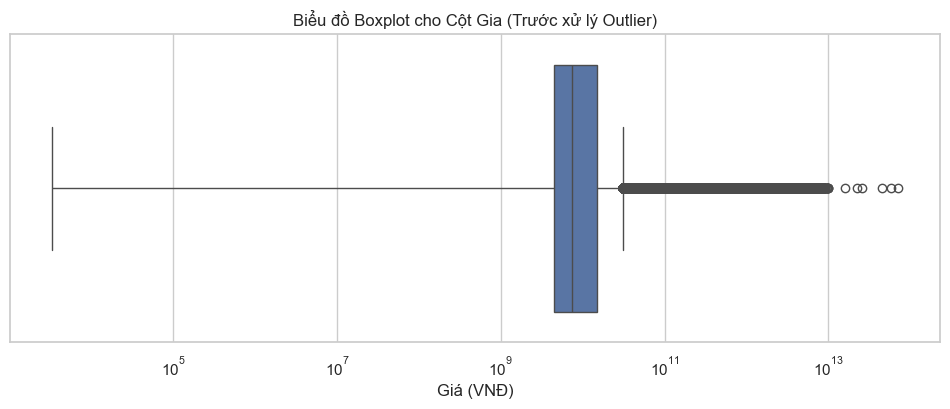

In [24]:
print("\n Bắt đầu kiểm tra Outliers bằng Boxplot...")
sns.set_theme(style="whitegrid")

# 1. Kiểm tra Cột 'Gia' 
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['Gia'])
plt.title('Biểu đồ Boxplot cho Cột Gia (Trước xử lý Outlier)')
plt.xlabel('Giá (VNĐ)')
plt.xscale('log') # Dùng thang log
plt.show()

* Phần lớn giá nhà tập trung trong khoảng $10^{9}$ tỷ đến $10^{10}$ (vài chục tỷ VND)
* Xuất hiện các outliers cực lớn và phi lý (lên đến $10^{13}$ VND), cần được xem xét loại bỏ để việc phân tích chính xác hơn

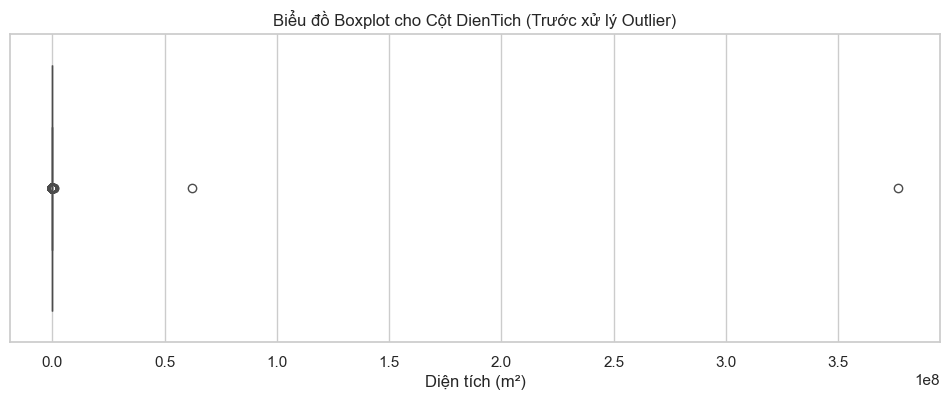

In [25]:
# 2. Kiểm tra Cột 'DienTich'
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['DienTich'])
plt.title('Biểu đồ Boxplot cho Cột DienTich (Trước xử lý Outlier)')
plt.xlabel('Diện tích (m²)')
# Có thể dùng xlim để zoom nếu cần: plt.xlim(0, df_final['DienTich'].quantile(0.99) * 1.1)
plt.show()

* Một điểm ở khoảng 0.5 x 10⁸ ($50,000,000 \, m^2$ hay 50 km²)
* Một điểm khác ở gần 3.8 x 10⁸ ($380,000,000 \, m^2$ hay 380 km²).
* Những con số này cực kỳ lớn và phi thực tế đối với một tin rao bán bất động sản thông thường

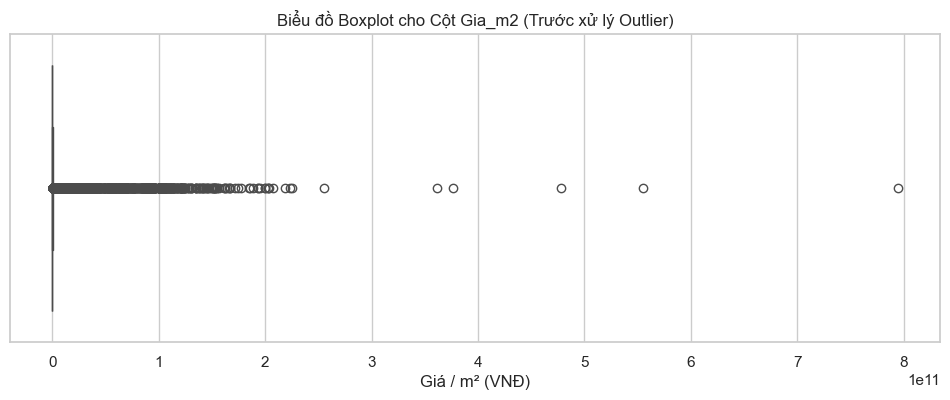

In [26]:
# 3. Kiểm tra Cột 'Gia_m2' 
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['Gia_m2'])
plt.title('Biểu đồ Boxplot cho Cột Gia_m2 (Trước xử lý Outlier)')
plt.xlabel('Giá / m² (VNĐ)')
# Có thể dùng xlim để zoom: plt.xlim(0, df_final['Gia_m2'].quantile(0.99) * 1.1)
plt.show()



* Phần hộp và râu bị nén chặt về phía bên trái, gần giá trị 0.
* Có rất nhiều điểm dữ liệu nằm rải rác và rất xa về phía bên phải của biểu đồ.


#### **10. Loại bỏ Outliers**

In [27]:
# Backup trước khi xử lý
df_before_outlier = df_final.copy()
print(f" Shape trước xử lý outliers: {df_before_outlier.shape}")

# Xử lý outliers cho Giá (Gia) theo từng Loại BĐS 
print("\n Xử lý outliers: Giá (theo phân vị 0.5% - 99.5% mỗi loại)")
df_temp_list_gia = []
for loai in df_final["LoaiBDS"].unique():
    # Bỏ qua loại không xác định
    if loai in ["CXD", "Không xác định"]:
        df_temp_list_gia.append(df_final[df_final["LoaiBDS"] == loai])
        continue

    subset = df_final[(df_final["LoaiBDS"] == loai) & (df_final["Gia"] > 0)]
    n_before = len(subset)

    if n_before < 50:  # Không xử lý nếu nhóm quá nhỏ
        df_temp_list_gia.append(subset)
        continue

    # Dùng percentile 0.5% - 99.5%
    lower = subset["Gia"].quantile(0.005)
    upper = subset["Gia"].quantile(0.995)

    # Lọc giữ lại dữ liệu trong khoảng
    subset_filtered = subset[(subset["Gia"] >= lower) & (subset["Gia"] <= upper)]
    n_after = len(subset_filtered)
    n_outliers = n_before - n_after

    df_temp_list_gia.append(subset_filtered)

    if n_outliers > 0:
        print(
            f"  • {loai:<15s}: Loại bỏ {n_outliers:5,} outliers "
            f"({n_outliers/n_before*100:5.2f}%) | "
            f"Giới hạn: {lower/1e6:.1f} tr - {upper/1e9:.2f} tỷ"
        )

# Ghép lại DataFrame sau khi xử lý Giá
df_final = pd.concat(df_temp_list_gia)
print(f" Shape sau xử lý outliers Giá: {df_final.shape}")


# Xử lý outliers cho Diện tích (DienTich) theo giới hạn cứng 
print("\n Xử lý outliers: Diện tích (theo giới hạn cứng mỗi loại)")
limits_dientich = {
    "Căn hộ": (20, 500),
    "Nhà": (20, 1000),
    "Đất": (30, 5000),
    "Biệt thự": (80, 2000),   # sửa từ 'Villa' -> 'Biệt thự'
    "Shophouse": (30, 600),
    "Mặt bằng/Shop": (10, 1000),
    "Phòng trọ": (10, 100),
    "Kho/Xưởng": (50, 10000),
    "Khách sạn/Nhà nghỉ": (50, 5000),
    # Các loại khác hoặc không xác định sẽ không bị lọc ở bước này
}

df_temp_list_dt = []
processed_loai = set()
for loai, (min_dt, max_dt) in limits_dientich.items():
    processed_loai.add(loai)
    subset = df_final[(df_final["LoaiBDS"] == loai) & (df_final["DienTich"] > 0)]
    n_before = len(subset)

    if n_before == 0:
        continue

    subset_filtered = subset[(subset["DienTich"] >= min_dt) & (subset["DienTich"] <= max_dt)]
    n_after = len(subset_filtered)
    n_outliers = n_before - n_after

    df_temp_list_dt.append(subset_filtered)

    if n_outliers > 0:
        print(f"  • {loai:<15s}: Loại bỏ {n_outliers:5,} outliers | Giới hạn: {min_dt}-{max_dt} m²")

# Thêm lại các loại không có trong limits
unprocessed_loai = df_final[~df_final["LoaiBDS"].isin(processed_loai)]
df_temp_list_dt.append(unprocessed_loai)

# Ghép lại DataFrame sau khi xử lý Diện tích
df_final = pd.concat(df_temp_list_dt)
print(f" Shape sau xử lý outliers Diện tích: {df_final.shape}")


# Xử lý outliers cho Giá/m2 (Gia_m2) theo từng Loại BĐS 
print("\n Xử lý outliers: Giá/m2 (theo phân vị 1% - 99% mỗi loại)")
df_temp_list_giam2 = []
for loai in df_final["LoaiBDS"].unique():
    # Bỏ qua loại không xác định
    if loai in ["CXD", "Không xác định"]:
        df_temp_list_giam2.append(df_final[df_final["LoaiBDS"] == loai])
        continue

    subset = df_final[(df_final["LoaiBDS"] == loai) & (df_final["Gia_m2"] > 0)]
    n_before = len(subset)

    if n_before < 50:
        df_temp_list_giam2.append(subset)
        continue

    # Dùng percentile 1% - 99%
    lower = subset["Gia_m2"].quantile(0.01)
    upper = subset["Gia_m2"].quantile(0.99)

    subset_filtered = subset[(subset["Gia_m2"] >= lower) & (subset["Gia_m2"] <= upper)]
    n_after = len(subset_filtered)
    n_outliers = n_before - n_after

    df_temp_list_giam2.append(subset_filtered)

    if n_outliers > 0:
        print(
            f"  • {loai:<15s}: Loại bỏ {n_outliers:5,} outliers | "
            f"Giới hạn: {lower/1e6:.1f} tr/m² - {upper/1e6:.1f} tr/m²"
        )

# Ghép lại DataFrame sau khi xử lý Giá/m2
df_final = pd.concat(df_temp_list_giam2)
print(f" Shape sau xử lý outliers Giá/m2: {df_final.shape}")


# Tổng kết xử lý Outliers 
print("\n" + "=" * 60)
print(" HOÀN TẤT XỬ LÝ OUTLIERS")
print("=" * 60)
print(f" Shape ban đầu (trước outlier): {df_before_outlier.shape}")
print(f" Shape cuối cùng (sau outlier):  {df_final.shape}")
removed_count = len(df_before_outlier) - len(df_final)
removed_pct = removed_count / len(df_before_outlier) * 100 if len(df_before_outlier) > 0 else 0
print(f"  Đã loại bỏ tổng cộng:       {removed_count:,} dòng ({removed_pct:.2f}%) do outliers.")

print("\n Xử lý Outliers hoàn tất.")


 Shape trước xử lý outliers: (122068, 19)

 Xử lý outliers: Giá (theo phân vị 0.5% - 99.5% mỗi loại)
  • Nhà            : Loại bỏ   689 outliers ( 1.00%) | Giới hạn: 449.2 tr - 1980.00 tỷ
  • Đất            : Loại bỏ   243 outliers ( 1.00%) | Giới hạn: 130.0 tr - 3457.30 tỷ
  • Căn hộ         : Loại bỏ   121 outliers ( 1.01%) | Giới hạn: 146.3 tr - 232.00 tỷ
  • Biệt thự       : Loại bỏ    52 outliers ( 1.02%) | Giới hạn: 3548.2 tr - 402.33 tỷ
 Shape sau xử lý outliers Giá: (120963, 19)

 Xử lý outliers: Diện tích (theo giới hạn cứng mỗi loại)
  • Căn hộ         : Loại bỏ    64 outliers | Giới hạn: 20-500 m²
  • Nhà            : Loại bỏ 1,117 outliers | Giới hạn: 20-1000 m²
  • Đất            : Loại bỏ   562 outliers | Giới hạn: 30-5000 m²
  • Biệt thự       : Loại bỏ   211 outliers | Giới hạn: 80-2000 m²
 Shape sau xử lý outliers Diện tích: (119009, 19)

 Xử lý outliers: Giá/m2 (theo phân vị 1% - 99% mỗi loại)
  • Căn hộ         : Loại bỏ   238 outliers | Giới hạn: 11.0 tr/m² - 346.0 

#### **11. Trực quan hóa Outliers (Sau khi xử lý)**

*Vẽ lại biểu đồ boxplot để xem hiệu quả của việc loại bỏ outlier.*

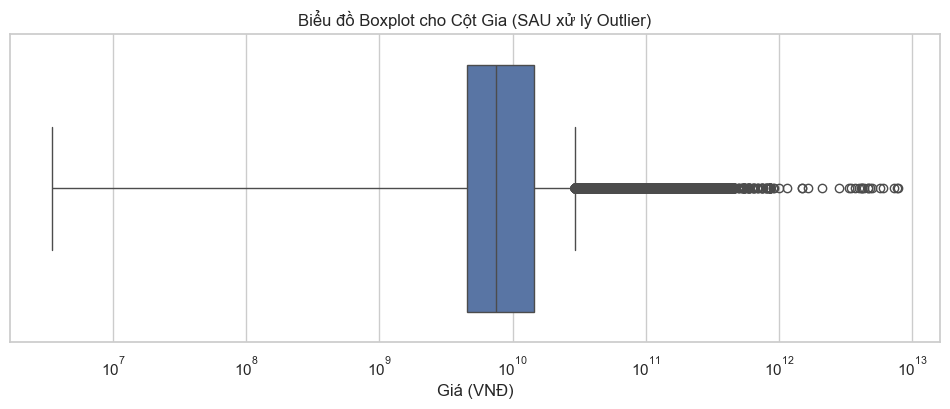

In [28]:
# 1. Kiểm tra Cột 'Gia' 
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['Gia'])
plt.title('Biểu đồ Boxplot cho Cột Gia (SAU xử lý Outlier)')
plt.xlabel('Giá (VNĐ)')
plt.xscale('log')
plt.show()

* Giá trị cao nhất của các outliers này chỉ đến khoảng $10^{12}$ (một nghìn tỷ) VND, thay vì $10^{13}$ (mười nghìn tỷ) như trước

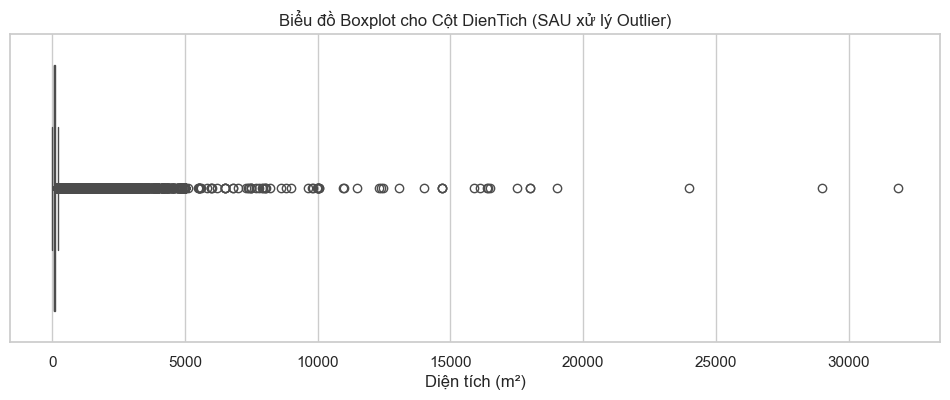

In [29]:
# 2. Kiểm tra Cột 'DienTich' 
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['DienTich'])
plt.title('Biểu đồ Boxplot cho Cột DienTich (SAU xử lý Outlier)')
plt.xlabel('Diện tích (m²)')
plt.show()

* Cái hộp (IQR - chứa 50% dữ liệu giữa) nằm ở khoảng diện tích tương đối nhỏ (có thể từ vài chục đến vài trăm m²).

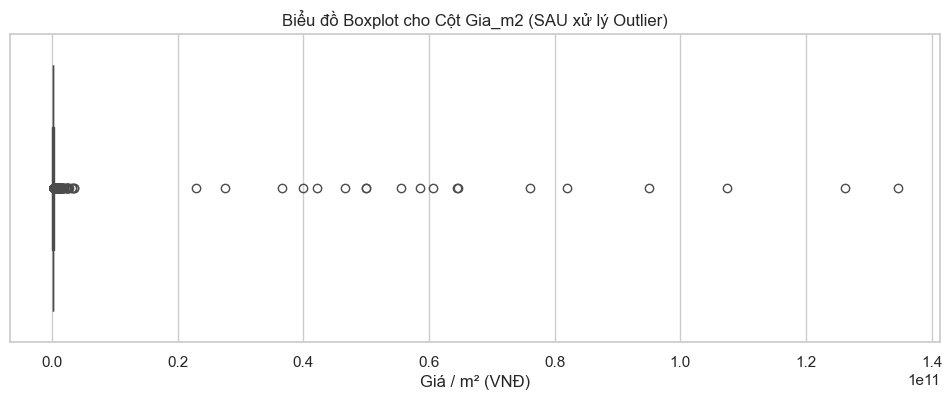

In [30]:
# 3. Kiểm tra Cột 'Gia_m2' 
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['Gia_m2'])
plt.title('Biểu đồ Boxplot cho Cột Gia_m2 (SAU xử lý Outlier)')
plt.xlabel('Giá / m² (VNĐ)')
plt.show()

* Vẫn còn khá nhiều outliers ở phía bên phải.
* Tuy nhiên, giá trị cao nhất của các outliers này (khoảng 20 tỷ VND/m²) đã thấp hơn rất nhiều so với trước khi xử lý (lên đến 800 tỷ VND/m²).
* Những outliers còn lại này, dù vẫn cao, nhưng có khả năng là giá thực tế của các bất động sản ở những vị trí cực kỳ đắc địa

In [33]:
display(df_final.sort_values("Gia", ascending=False)[["TieuDe", "LoaiBDS", "QuanHuyen", "Gia", "DienTich", "Gia_m2", "Nguon"]].head(5))
display(df_final.sort_values("Gia_m2", ascending=False)[["TieuDe", "LoaiBDS", "QuanHuyen", "Gia", "DienTich", "Gia_m2", "Nguon"]].head(5))
display(df_final.sort_values("DienTich", ascending=False)[["TieuDe", "LoaiBDS", "QuanHuyen", "Gia", "DienTich", "Gia_m2", "Nguon"]].head(5))

,TieuDe,LoaiBDS,QuanHuyen,Gia,DienTich,Gia_m2,Nguon
154471,"Cực sốc 121m, ngang khủng 9m hxh thông huỳnh t...",Không xác định,Quận 7,7.800000e+12,121.0,6.446281e+10,nhadat24h
120793,Ng hiếm có - vị trí đẹp 61m2 đường hoàng hoa t...,Không xác định,Bình Thạnh,7.700000e+12,61.0,1.262295e+11,nhadat24h
120977,Hàng hiếm có 1 không 2- 68m2 hẻm thông đường ...,Không xác định,Bình Thạnh,7.300000e+12,68.0,1.073529e+11,nhadat24h
135446,"Siêu phẩm 150m2 tây hoà phước long a, dòng tiề...",Không xác định,Thủ Đức,6.000000e+12,150.0,4.000000e+10,nhadat24h
136940,Bán lô góc 2 mặt tiền 135m2 - ngang 4.4m - hẻm...,Không xác định,Thủ Đức,5.700000e+12,135.0,4.222222e+10,nhadat24h


,TieuDe,LoaiBDS,QuanHuyen,Gia,DienTich,Gia_m2,Nguon
149155,Trần xuân soạn - ngang 5m - 3.5 tỷ - ở ngay,Không xác định,Quận 7,3.500000e+12,26.0,1.346154e+11,nhadat24h
120793,Ng hiếm có - vị trí đẹp 61m2 đường hoàng hoa t...,Không xác định,Bình Thạnh,7.700000e+12,61.0,1.262295e+11,nhadat24h
120977,Hàng hiếm có 1 không 2- 68m2 hẻm thông đường ...,Không xác định,Bình Thạnh,7.300000e+12,68.0,1.073529e+11,nhadat24h
156281,Ban nha 3x10 duong 18b bhha binh tan. hem xe h...,Không xác định,Bình Tân,2.850000e+12,30.0,9.500000e+10,nhadat24h
155103,"Ngộp bank võ văn ngân,linh chiểu, thủ đức 50m2...",Không xác định,Thủ Đức,4.100000e+12,50.0,8.200000e+10,nhadat24h


,TieuDe,LoaiBDS,QuanHuyen,Gia,DienTich,Gia_m2,Nguon
5891,"BÁN KHO XƯỞNG 31.000M2 TẠI BÌNH CHÁNH, TPHCM- ...",Không xác định,Bình Chánh,1.000000e+07,31848.0,313.99,alonhadat
20471,"Vip! Bán siêu phẩm 4 mặt tiền Trương Văn Bang,...",Không xác định,Thủ Đức,4.350000e+11,29000.0,15000000.00,batdongsan
25092,Cần bán gấp resort 4 sao tại KDL biển Mũi Né -...,Không xác định,Quận 1,6.300000e+11,24000.0,26250000.00,batdongsan
42188,"Chỉ 4.5 triệu/m2 mặt tiền Trần Đại Nghĩa, Bình...",Không xác định,Bình Chánh,8.500000e+10,19000.0,4473684.21,batdongsan
12739,"Giảm 1,5 tỷ - Bán kho xưởng - Mặt tiền Võ Văn ...",Không xác định,Củ Chi,1.350000e+10,18000.0,750000.00,alonhadat


* `Gia_m2` sau xử lý vẫn còn khá nhiều outliers ở phía bên phải.
* Các giá trị cực lớn còn lại chủ yếu xuất hiện ở nhóm `Không xác định`, phản ánh dữ liệu nhiễu hoặc tin đăng có mô tả chưa chuẩn.
* Vì vậy, có thể kết luận rằng bước lọc outlier đã cải thiện phân bố giá, nhưng chưa loại bỏ hoàn toàn các cực trị ở toàn bộ dataset.


### **12. Xuất Kết Quả**

*Lưu DataFrame `df_final` đã được làm sạch và xử lý ra file CSV mới.*

In [34]:
# Cell export cuối
current_dir = Path(os.getcwd())
output_filename = (current_dir / 'data' / 'processed' / 'fulldata_clean_4web.csv') if (current_dir / 'data').exists() else (current_dir.parent.parent / 'data' / 'processed' / 'fulldata_clean_4web.csv')
print("\n Bắt đầu xuất DataFrame cuối cùng ra file CSV")

output_filename.parent.mkdir(parents=True, exist_ok=True)
df_final.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(" HOÀN TẤT TIỀN XỬ LÝ!")
print(f" File kết quả: {output_filename}")
print(f" Shape cuối cùng: {df_final.shape}")


 Bắt đầu xuất DataFrame cuối cùng ra file CSV
 HOÀN TẤT TIỀN XỬ LÝ!
 File kết quả: c:\Users\ADMIN\Documents\CODE\bds_hcm_project_data\data\processed\fulldata_clean_4web.csv
 Shape cuối cùng: (116863, 19)
